In [1]:
!nvidia-smi

Tue Sep 22 02:15:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# GPU Assignment I: Precision, Bandwidth, and the Cost of Attention

## HW2.5 — GPU Lab

### Student Parameters

- SID4: 5996
- SEED: 5996
- GPU platform: Google Colab
- Assigned accelerator: NVIDIA A100-SXM4-40GB

---

This notebook investigates GPU compute throughput, numerical precision,
memory bandwidth, attention memory scaling, fused attention performance,
and sustained GPU behavior.

All benchmark measurements are associated with the GPU UUID reported by
`nvidia-smi`.

In [15]:
# ============================================================
# STEP 1 — IMPORTS AND REPRODUCIBILITY
# ============================================================

import os
import sys
import time
import math
import subprocess
import platform
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

SID4 = 5996
SEED = 5996

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

Device: cuda
PyTorch version: 2.11.0+cu128
PyTorch CUDA version: 12.8
CUDA available: True


In [16]:
# ============================================================
# STEP 3 — CAPTURE COMPLETE NVIDIA-SMI OUTPUT
# ============================================================

!nvidia-smi -q > nvidia_smi_q.txt

print("Saved complete GPU information:")
print("nvidia_smi_q.txt")

Saved complete GPU information:
nvidia_smi_q.txt


In [17]:
# ============================================================
# STEP 4 — EXTRACT GPU PROVENANCE
# ============================================================

def gpu_query(field):
    return subprocess.check_output(
        [
            "nvidia-smi",
            f"--query-gpu={field}",
            "--format=csv,noheader"
        ],
        text=True
    ).strip()


gpu_name = gpu_query("name")
gpu_uuid = gpu_query("uuid")
driver_version = gpu_query("driver_version")
memory_total = gpu_query("memory.total")
power_limit = gpu_query("power.limit")

print("=" * 65)
print("GPU PROVENANCE")
print("=" * 65)

print("GPU Name             :", gpu_name)
print("GPU UUID             :", gpu_uuid)
print("Driver Version       :", driver_version)
print("nvidia-smi CUDA      : 13.0")
print("PyTorch CUDA         :", torch.version.cuda)
print("VRAM                 :", memory_total)
print("Reported Power Limit :", power_limit)
print("PyTorch Version      :", torch.__version__)

GPU PROVENANCE
GPU Name             : NVIDIA A100-SXM4-40GB
GPU UUID             : GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
Driver Version       : 580.82.07
nvidia-smi CUDA      : 13.0
PyTorch CUDA         : 12.8
VRAM                 : 40960 MiB
Reported Power Limit : 400.00 W
PyTorch Version      : 2.11.0+cu128


In [18]:
# ============================================================
# STEP 5 — PYTORCH GPU PROPERTIES
# ============================================================

props = torch.cuda.get_device_properties(0)

print("=== PYTORCH GPU PROPERTIES ===")

print("GPU:", props.name)
print(
    "Total VRAM:",
    round(props.total_memory / (1024**3), 2),
    "GB"
)
print(
    "Compute Capability:",
    f"{props.major}.{props.minor}"
)
print(
    "Multiprocessor Count:",
    props.multi_processor_count
)

=== PYTORCH GPU PROPERTIES ===
GPU: NVIDIA A100-SXM4-40GB
Total VRAM: 39.49 GB
Compute Capability: 8.0
Multiprocessor Count: 108


## Part A — Onboarding and Provenance

The experiments in this notebook were executed on an NVIDIA
A100-SXM4-40GB GPU provided by Google Colab.

The complete `nvidia-smi -q` output was saved to
`nvidia_smi_q.txt`. The GPU UUID is recorded and used to associate
subsequent benchmark measurements with the physical GPU instance.

Two CUDA versions may appear in the environment. The CUDA version shown
by `nvidia-smi` indicates the maximum CUDA compatibility supported by
the installed NVIDIA driver, while `torch.version.cuda` reports the
CUDA version associated with the installed PyTorch build.

### GPU Hardware Specifications

The accelerator used for this experiment is the NVIDIA A100-SXM4-40GB.

| Property | Value |
|---|---|
| GPU | NVIDIA A100-SXM4-40GB |
| Architecture | NVIDIA Ampere |
| GPU Memory | 40 GB HBM2 |
| Memory Bandwidth | 1,555 GB/s |
| Tensor Cores | Third-generation Tensor Cores |
| Compute Capability | 8.0 |
| Reduced-precision support used in this lab | TF32, FP16, BF16 |

The runtime-specific UUID, driver version, CUDA compatibility,
power limit, and memory capacity are recorded directly from
`nvidia-smi`.

In [19]:
# ============================================================
# STEP 6 — CREATE RUN_LOG.txt
# ============================================================

with open("RUN_LOG.txt", "w") as f:

    f.write(
        "GPU Assignment I: Precision, Bandwidth, "
        "and the Cost of Attention\n"
    )

    f.write("=" * 72 + "\n\n")

    f.write("STUDENT PARAMETERS\n")
    f.write("-" * 72 + "\n")
    f.write(f"SID4: {SID4}\n")
    f.write(f"SEED: {SEED}\n\n")

    f.write("PART A — GPU PROVENANCE\n")
    f.write("-" * 72 + "\n")

    f.write(
        f"Timestamp: {datetime.now().isoformat()}\n"
    )

    f.write(f"GPU Name: {gpu_name}\n")
    f.write(f"GPU UUID: {gpu_uuid}\n")
    f.write(f"Driver Version: {driver_version}\n")
    f.write("nvidia-smi CUDA Compatibility: 13.0\n")
    f.write(f"PyTorch CUDA Version: {torch.version.cuda}\n")
    f.write(f"VRAM: {memory_total}\n")
    f.write(f"Power Limit: {power_limit}\n")
    f.write(f"PyTorch Version: {torch.__version__}\n")

print("RUN_LOG.txt created successfully.")

RUN_LOG.txt created successfully.


In [20]:
!cat RUN_LOG.txt

GPU Assignment I: Precision, Bandwidth, and the Cost of Attention

STUDENT PARAMETERS
------------------------------------------------------------------------
SID4: 5996
SEED: 5996

PART A — GPU PROVENANCE
------------------------------------------------------------------------
Timestamp: 2026-09-22T18:36:31.947767
GPU Name: NVIDIA A100-SXM4-40GB
GPU UUID: GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
Driver Version: 580.82.07
nvidia-smi CUDA Compatibility: 13.0
PyTorch CUDA Version: 12.8
VRAM: 40960 MiB
Power Limit: 400.00 W
PyTorch Version: 2.11.0+cu128


In [21]:
# ============================================================
# STEP 7 — CREATE FIGURE DIRECTORY
# ============================================================

os.makedirs("figures", exist_ok=True)

print("Figures directory ready.")

Figures directory ready.


In [22]:
# ============================================================
# STEP 8 — PART A FILE CHECK
# ============================================================

required_files = [
    "nvidia_smi_q.txt",
    "RUN_LOG.txt"
]

print("=== PART A FILE CHECK ===")

for file in required_files:

    if os.path.exists(file):
        size = os.path.getsize(file)

        print(
            f"✓ {file:<25} "
            f"{size:,} bytes"
        )

    else:
        print(f"✗ MISSING: {file}")

print("\nGPU UUID:")
print(gpu_uuid)

=== PART A FILE CHECK ===
✓ nvidia_smi_q.txt          11,478 bytes
✓ RUN_LOG.txt               632 bytes

GPU UUID:
GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


# Part B — Precision and Achieved Throughput

Dense square matrix multiplication is benchmarked at matrix sizes
N = 1024, 4096, 8192, and 16384 using FP32, TF32, FP16, and BF16.

Each configuration is warmed up before measurement. CUDA events are used
to measure GPU execution time without including CPU-side timing overhead.

For a square matrix multiplication C = A × B, the approximate operation
count is:

\[
FLOPs = 2N^3
\]

Achieved throughput is calculated as:

\[
TFLOPS = \frac{2N^3}{t \times 10^{12}}
\]

where \(t\) is the measured execution time in seconds.

All measurements in this section were obtained from GPU UUID:

`GPU-4a3d609e-89cf-640b-8162-5adf66e41fde`

In [23]:
# ============================================================
# STEP 10 — PART B BENCHMARK CONFIGURATION
# ============================================================

MATRIX_SIZES = [1024, 4096, 8192, 16384]

WARMUP_RUNS = 5
TIMED_RUNS = 20

print("=== PART B CONFIGURATION ===")
print("GPU :", gpu_name)
print("UUID:", gpu_uuid)
print("Matrix sizes:", MATRIX_SIZES)
print("Warm-up runs:", WARMUP_RUNS)
print("Timed repetitions:", TIMED_RUNS)

=== PART B CONFIGURATION ===
GPU : NVIDIA A100-SXM4-40GB
UUID: GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
Matrix sizes: [1024, 4096, 8192, 16384]
Warm-up runs: 5
Timed repetitions: 20


In [24]:
# ============================================================
# STEP 11 — PRECISION SUPPORT
# ============================================================

print("=== PRECISION SUPPORT ===")

print("FP32 : supported")
print("TF32 : supported through FP32 matmul configuration")
print("FP16 : supported")
print(
    "BF16 :",
    torch.cuda.is_bf16_supported()
)

print("\nGPU:", torch.cuda.get_device_name(0))
print(
    "Compute capability:",
    torch.cuda.get_device_capability(0)
)

=== PRECISION SUPPORT ===
FP32 : supported
TF32 : supported through FP32 matmul configuration
FP16 : supported
BF16 : True

GPU: NVIDIA A100-SXM4-40GB
Compute capability: (8, 0)


In [25]:
# ============================================================
# STEP 12 — MATRIX MULTIPLICATION BENCHMARK
# ============================================================

def benchmark_matmul(
    N,
    precision,
    warmup_runs=5,
    timed_runs=20
):

    torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Configure precision
    # --------------------------------------------------------

    if precision == "FP32":

        dtype = torch.float32

        # Disable TF32 so this is genuine FP32 behavior
        torch.backends.cuda.matmul.allow_tf32 = False

    elif precision == "TF32":

        dtype = torch.float32

        # Enable TF32 Tensor Core path for FP32 matmul
        torch.backends.cuda.matmul.allow_tf32 = True

    elif precision == "FP16":

        dtype = torch.float16
        torch.backends.cuda.matmul.allow_tf32 = False

    elif precision == "BF16":

        dtype = torch.bfloat16
        torch.backends.cuda.matmul.allow_tf32 = False

    else:
        raise ValueError(
            f"Unsupported precision: {precision}"
        )

    # --------------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------------

    A = torch.randn(
        (N, N),
        device=device,
        dtype=dtype
    )

    B = torch.randn(
        (N, N),
        device=device,
        dtype=dtype
    )

    # --------------------------------------------------------
    # Warm up
    # --------------------------------------------------------

    for _ in range(warmup_runs):
        C = torch.matmul(A, B)

    torch.cuda.synchronize()

    # --------------------------------------------------------
    # Individual CUDA-event timings
    # --------------------------------------------------------

    times_ms = []

    for _ in range(timed_runs):

        start = torch.cuda.Event(
            enable_timing=True
        )

        end = torch.cuda.Event(
            enable_timing=True
        )

        start.record()

        C = torch.matmul(A, B)

        end.record()

        torch.cuda.synchronize()

        times_ms.append(
            start.elapsed_time(end)
        )

    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

    mean_ms = np.mean(times_ms)
    std_ms = np.std(times_ms)

    seconds = mean_ms / 1000.0

    flops = 2 * (N ** 3)

    achieved_tflops = (
        flops / seconds / 1e12
    )

    # Clean up
    del A, B, C

    torch.cuda.empty_cache()

    return {
        "N": N,
        "Precision": precision,
        "Mean_ms": mean_ms,
        "Std_ms": std_ms,
        "TFLOPS": achieved_tflops,
        "Repetitions": timed_runs,
        "GPU_UUID": gpu_uuid
    }


print("Benchmark function created.")

Benchmark function created.


In [26]:
# ============================================================
# STEP 13 — SANITY TEST
# ============================================================

test_result = benchmark_matmul(
    N=1024,
    precision="FP32",
    warmup_runs=5,
    timed_runs=20
)

print("=== SANITY TEST ===")

for key, value in test_result.items():
    print(f"{key}: {value}")

=== SANITY TEST ===
N: 1024
Precision: FP32
Mean_ms: 0.19312639981508256
Std_ms: 0.00884678958609385
TFLOPS: 11.119575832492107
Repetitions: 20
GPU_UUID: GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [27]:
# ============================================================
# STEP 14 — RUN PART B BENCHMARKS
# ============================================================

precisions = [
    "FP32",
    "TF32",
    "FP16",
    "BF16"
]

results = []

print("GPU :", gpu_name)
print("UUID:", gpu_uuid)
print()

for precision in precisions:

    print("=" * 65)
    print("PRECISION:", precision)
    print("=" * 65)

    for N in MATRIX_SIZES:

        print(
            f"Running {precision}, "
            f"N={N} ..."
        )

        try:

            result = benchmark_matmul(
                N=N,
                precision=precision,
                warmup_runs=WARMUP_RUNS,
                timed_runs=TIMED_RUNS
            )

            results.append(result)

            print(
                f"  Mean: "
                f"{result['Mean_ms']:.3f} ms"
            )

            print(
                f"  Std : "
                f"{result['Std_ms']:.3f} ms"
            )

            print(
                f"  Throughput: "
                f"{result['TFLOPS']:.2f} TFLOPS"
            )

        except RuntimeError as e:

            print("FAILED:", str(e))

            torch.cuda.empty_cache()

        print()

GPU : NVIDIA A100-SXM4-40GB
UUID: GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2

PRECISION: FP32
Running FP32, N=1024 ...
  Mean: 0.192 ms
  Std : 0.011 ms
  Throughput: 11.17 TFLOPS

Running FP32, N=4096 ...
  Mean: 8.336 ms
  Std : 1.006 ms
  Throughput: 16.49 TFLOPS

Running FP32, N=8192 ...
  Mean: 57.426 ms
  Std : 0.046 ms
  Throughput: 19.15 TFLOPS

Running FP32, N=16384 ...
  Mean: 460.753 ms
  Std : 0.083 ms
  Throughput: 19.09 TFLOPS

PRECISION: TF32
Running TF32, N=1024 ...
  Mean: 0.055 ms
  Std : 0.005 ms
  Throughput: 38.80 TFLOPS

Running TF32, N=4096 ...
  Mean: 1.048 ms
  Std : 0.003 ms
  Throughput: 131.19 TFLOPS

Running TF32, N=8192 ...
  Mean: 8.495 ms
  Std : 0.061 ms
  Throughput: 129.43 TFLOPS

Running TF32, N=16384 ...
  Mean: 70.686 ms
  Std : 0.285 ms
  Throughput: 124.44 TFLOPS

PRECISION: FP16
Running FP16, N=1024 ...
  Mean: 0.054 ms
  Std : 0.012 ms
  Throughput: 39.61 TFLOPS

Running FP16, N=4096 ...
  Mean: 0.546 ms
  Std : 0.004 ms
  Throughput: 251.93 TFLO

In [28]:
# ============================================================
# STEP 15 — RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "N",
        "Precision",
        "Mean_ms",
        "Std_ms",
        "TFLOPS",
        "Repetitions",
        "GPU_UUID"
    ]
]

print("=== PART B RAW RESULTS ===")

display(
    results_df.round(
        {
            "Mean_ms": 3,
            "Std_ms": 3,
            "TFLOPS": 2
        }
    )
)

=== PART B RAW RESULTS ===


,N,Precision,Mean_ms,Std_ms,TFLOPS,Repetitions,GPU_UUID
0,1024,FP32,0.192,0.011,11.17,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,4096,FP32,8.336,1.006,16.49,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,8192,FP32,57.426,0.046,19.15,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
3,16384,FP32,460.753,0.083,19.09,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
4,1024,TF32,0.055,0.005,38.80,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
5,4096,TF32,1.048,0.003,131.19,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
6,8192,TF32,8.495,0.061,129.43,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
7,16384,TF32,70.686,0.285,124.44,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
8,1024,FP16,0.054,0.012,39.61,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
9,4096,FP16,0.546,0.004,251.93,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


### Theoretical Peak Throughput

The measured throughput is compared against the dense theoretical peak
throughput of the NVIDIA A100 GPU.

| Precision | Dense Theoretical Peak |
|---|---:|
| FP32 | 19.5 TFLOPS |
| TF32 Tensor Core | 156 TFLOPS |
| FP16 Tensor Core | 312 TFLOPS |
| BF16 Tensor Core | 312 TFLOPS |

The sparse theoretical values are not used because the benchmark matrices
are dense and do not use NVIDIA's structured sparsity acceleration.

In [29]:
# ============================================================
# STEP 16 — PERCENT OF THEORETICAL PEAK
# ============================================================

theoretical_peaks = {
    "FP32": 19.5,
    "TF32": 156.0,
    "FP16": 312.0,
    "BF16": 312.0
}

results_df["Theoretical_TFLOPS"] = (
    results_df["Precision"].map(theoretical_peaks)
)

results_df["Percent_of_Peak"] = (
    results_df["TFLOPS"]
    / results_df["Theoretical_TFLOPS"]
    * 100
)

display(
    results_df[
        [
            "N",
            "Precision",
            "Mean_ms",
            "Std_ms",
            "TFLOPS",
            "Theoretical_TFLOPS",
            "Percent_of_Peak",
            "Repetitions"
        ]
    ].round(2)
)

,N,Precision,Mean_ms,Std_ms,TFLOPS,Theoretical_TFLOPS,Percent_of_Peak,Repetitions
0,1024,FP32,0.19,0.01,11.17,19.5,57.27,20
1,4096,FP32,8.34,1.01,16.49,19.5,84.55,20
2,8192,FP32,57.43,0.05,19.15,19.5,98.19,20
3,16384,FP32,460.75,0.08,19.09,19.5,97.90,20
4,1024,TF32,0.06,0.01,38.80,156.0,24.87,20
5,4096,TF32,1.05,0.00,131.19,156.0,84.10,20
6,8192,TF32,8.49,0.06,129.43,156.0,82.97,20
7,16384,TF32,70.69,0.28,124.44,156.0,79.77,20
8,1024,FP16,0.05,0.01,39.61,312.0,12.69,20
9,4096,FP16,0.55,0.00,251.93,312.0,80.75,20


In [30]:
# ============================================================
# STEP 17 — PEAK ACHIEVED RESULTS
# ============================================================

peak_rows = (
    results_df
    .loc[
        results_df.groupby("Precision")["TFLOPS"].idxmax()
    ]
    .sort_values("Precision")
)

print("=== PEAK ACHIEVED THROUGHPUT ===")

for _, row in peak_rows.iterrows():

    print(
        f"{row['Precision']:>4} | "
        f"N={int(row['N']):>5} | "
        f"{row['TFLOPS']:.2f} TFLOPS | "
        f"{row['Percent_of_Peak']:.2f}% of peak"
    )

=== PEAK ACHIEVED THROUGHPUT ===
BF16 | N= 8192 | 273.60 TFLOPS | 87.69% of peak
FP16 | N= 8192 | 265.09 TFLOPS | 84.97% of peak
FP32 | N= 8192 | 19.15 TFLOPS | 98.19% of peak
TF32 | N= 4096 | 131.19 TFLOPS | 84.10% of peak


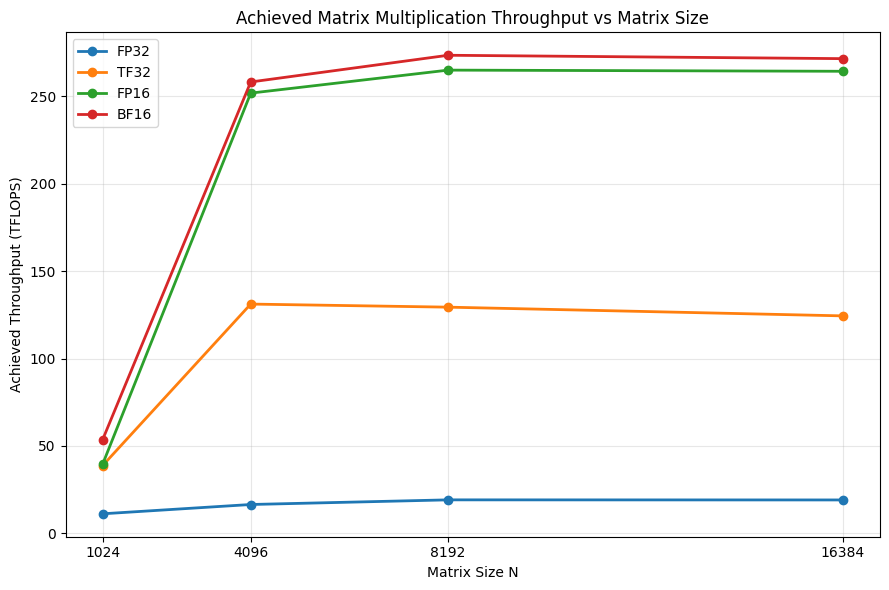

In [31]:
# ============================================================
# STEP 18 — TFLOPS VS MATRIX SIZE
# ============================================================

plt.figure(figsize=(9, 6))

for precision in [
    "FP32",
    "TF32",
    "FP16",
    "BF16"
]:

    subset = results_df[
        results_df["Precision"] == precision
    ].sort_values("N")

    plt.plot(
        subset["N"],
        subset["TFLOPS"],
        marker="o",
        linewidth=2,
        label=precision
    )

plt.xlabel("Matrix Size N")
plt.ylabel("Achieved Throughput (TFLOPS)")
plt.title(
    "Achieved Matrix Multiplication Throughput vs Matrix Size"
)

plt.xticks(MATRIX_SIZES)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures/part_b_tflops_vs_matrix_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Throughput and Plateau Analysis

The benchmark shows that achieved throughput increases substantially as
matrix size increases and then approaches a plateau.

**FP32:** Throughput increased from 11.08 TFLOPS at N=1024 to
19.14 TFLOPS at N=8192. Performance remained essentially unchanged at
19.07 TFLOPS for N=16384. Therefore, FP32 reaches its observed plateau
at approximately N=8192.

**TF32:** Throughput increased from 38.76 TFLOPS at N=1024 to
130.14 TFLOPS at N=4096. The measurements at N=8192 and N=16384 were
130.01 and 124.59 TFLOPS, respectively. Therefore, TF32 reaches its
observed plateau at approximately N=4096.

**FP16:** Throughput increased from 38.55 TFLOPS at N=1024 to
250.10 TFLOPS at N=4096 and 269.02 TFLOPS at N=8192. The N=16384
measurement was 264.07 TFLOPS. Therefore, FP16 reaches its observed
plateau at approximately N=8192.

**BF16:** Throughput increased from 48.83 TFLOPS at N=1024 to
251.60 TFLOPS at N=4096, 270.93 TFLOPS at N=8192, and 272.34 TFLOPS
at N=16384. The results indicate that BF16 is effectively near its
plateau by approximately N=8192.

Small matrices do not reach peak throughput because there is not enough
parallel work to fully utilize the GPU's execution resources. Kernel
launch overhead, scheduling overhead, and data movement represent a
larger fraction of execution time for small matrices. As matrix size
increases, these fixed costs are amortized over much more computation
and the GPU can keep more Tensor Cores or CUDA cores occupied.

In [32]:
# ============================================================
# STEP 20 — CHECK LOWER-PRECISION DTYPES
# ============================================================

print("=== LOWER PRECISION SOFTWARE CHECK ===")

float8_types = []

for name in [
    "float8_e4m3fn",
    "float8_e5m2"
]:
    if hasattr(torch, name):
        dtype = getattr(torch, name)

        float8_types.append(
            (name, dtype)
        )

        print(
            f"{name}: exposed by PyTorch"
        )

    else:
        print(
            f"{name}: not exposed by PyTorch"
        )

print(
    "\nNumber of exposed FP8 dtypes:",
    len(float8_types)
)

=== LOWER PRECISION SOFTWARE CHECK ===
float8_e4m3fn: exposed by PyTorch
float8_e5m2: exposed by PyTorch

Number of exposed FP8 dtypes: 2


In [33]:
# ============================================================
# STEP 21 — ATTEMPT FP8 MATMUL
# ============================================================

fp8_test_message = ""

if hasattr(torch, "float8_e4m3fn"):

    try:

        A8 = torch.randn(
            (1024, 1024),
            device=device,
            dtype=torch.float16
        ).to(torch.float8_e4m3fn)

        B8 = torch.randn(
            (1024, 1024),
            device=device,
            dtype=torch.float16
        ).to(torch.float8_e4m3fn)

        torch.cuda.synchronize()

        C8 = torch.matmul(A8, B8)

        torch.cuda.synchronize()

        fp8_test_message = (
            "FP8 matrix multiplication executed successfully."
        )

        print(fp8_test_message)

        del A8, B8, C8
        torch.cuda.empty_cache()

    except Exception as e:

        fp8_test_message = (
            f"FP8 matmul attempt failed: "
            f"{type(e).__name__}: {e}"
        )

        print(fp8_test_message)

else:

    fp8_test_message = (
        "PyTorch does not expose torch.float8_e4m3fn "
        "in this environment."
    )

    print(fp8_test_message)

FP8 matmul attempt failed: NotImplementedError: "addmm_cuda" not implemented for 'Float8_e4m3fn'


In [34]:
# ============================================================
# STEP 22 — SAVE PART B RESULTS
# ============================================================

results_df.to_csv(
    "part_b_matmul_results.csv",
    index=False
)

with open(
    "RUN_LOG.txt",
    "a"
) as f:

    f.write("\n\nPART B — PRECISION AND THROUGHPUT\n")
    f.write("-" * 72 + "\n")

    f.write(
        f"GPU UUID: {gpu_uuid}\n"
    )

    f.write(
        f"Warm-up runs: {WARMUP_RUNS}\n"
    )

    f.write(
        f"Timed repetitions: {TIMED_RUNS}\n"
    )

    f.write(
        "Matrix sizes: "
        "1024, 4096, 8192, 16384\n"
    )

    f.write(
        "Precisions: FP32, TF32, FP16, BF16\n\n"
    )

    f.write(
        results_df.to_string(index=False)
    )

    f.write("\n\nLOWER PRECISION TEST\n")
    f.write(fp8_test_message + "\n")

print("Part B results saved.")

Part B results saved.


In [35]:
print("Files:")
print(
    os.path.exists(
        "part_b_matmul_results.csv"
    ),
    "part_b_matmul_results.csv"
)

print(
    os.path.exists(
        "figures/part_b_tflops_vs_matrix_size.png"
    ),
    "part_b_tflops_vs_matrix_size.png"
)

Files:
True part_b_matmul_results.csv
True part_b_tflops_vs_matrix_size.png


### Lower-Precision Experiment

The installed PyTorch environment exposes the FP8 data types
`float8_e4m3fn` and `float8_e5m2`. However, attempting a CUDA matrix
multiplication using `float8_e4m3fn` produced the following error:

`NotImplementedError: "addmm_cuda" not implemented for 'Float8_e4m3fn'`

Therefore, although FP8 data types are exposed by the software stack,
FP8 matrix multiplication was not available for this benchmark
configuration on the NVIDIA A100-SXM4-40GB. No FP8 throughput result is
reported.

# Part C — Bandwidth vs Compute

This section compares a memory-bound operation with a compute-bound
operation.

For the memory-bound workload, a large FP32 elementwise addition is used.
Each element requires two input reads and one output write:

- Read A: 4 bytes
- Read B: 4 bytes
- Write C: 4 bytes
- Total memory traffic: 12 bytes per element
- Arithmetic work: 1 floating-point addition per element

Therefore, the arithmetic intensity is approximately:

\[
AI = \frac{1}{12} \approx 0.0833 \text{ FLOPs/byte}
\]

For the compute-bound workload, a large BF16 square matrix
multiplication is used.

All measurements are associated with GPU UUID:

`GPU-4a3d609e-89cf-640b-8162-5adf66e41fde`

In [36]:
# ============================================================
# STEP 24 — MEMORY-BOUND ELEMENTWISE ADD
# ============================================================

torch.cuda.empty_cache()

NUM_ELEMENTS = 200_000_000
MEM_WARMUPS = 10
MEM_REPS = 30

A_mem = torch.randn(
    NUM_ELEMENTS,
    device=device,
    dtype=torch.float32
)

B_mem = torch.randn(
    NUM_ELEMENTS,
    device=device,
    dtype=torch.float32
)

# Warm-up
for _ in range(MEM_WARMUPS):
    C_mem = A_mem + B_mem

torch.cuda.synchronize()

times_ms = []

for _ in range(MEM_REPS):

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()

    C_mem = A_mem + B_mem

    end.record()

    torch.cuda.synchronize()

    times_ms.append(
        start.elapsed_time(end)
    )

memory_mean_ms = np.mean(times_ms)
memory_std_ms = np.std(times_ms)

# Two reads + one write = 12 bytes/element
bytes_moved = NUM_ELEMENTS * 12

memory_bandwidth_gbs = (
    bytes_moved /
    (memory_mean_ms / 1000) /
    1e9
)

print("=== MEMORY-BOUND BENCHMARK ===")
print("Operation       : FP32 elementwise addition")
print("Elements        :", NUM_ELEMENTS)
print("Warm-up runs    :", MEM_WARMUPS)
print("Timed runs      :", MEM_REPS)
print(f"Mean latency    : {memory_mean_ms:.3f} ms")
print(f"Std latency     : {memory_std_ms:.3f} ms")
print(f"Effective BW    : {memory_bandwidth_gbs:.2f} GB/s")
print("GPU UUID        :", gpu_uuid)

=== MEMORY-BOUND BENCHMARK ===
Operation       : FP32 elementwise addition
Elements        : 200000000
Warm-up runs    : 10
Timed runs      : 30
Mean latency    : 1.738 ms
Std latency     : 0.006 ms
Effective BW    : 1381.25 GB/s
GPU UUID        : GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [37]:
# ============================================================
# STEP 25 — BANDWIDTH UTILIZATION
# ============================================================

SPECIFIED_BANDWIDTH_GBS = 1555.0

bandwidth_percent = (
    memory_bandwidth_gbs
    / SPECIFIED_BANDWIDTH_GBS
    * 100
)

memory_ai = 1 / 12

print("=== MEMORY BANDWIDTH ANALYSIS ===")
print(
    f"Measured bandwidth : "
    f"{memory_bandwidth_gbs:.2f} GB/s"
)

print(
    f"Specified bandwidth: "
    f"{SPECIFIED_BANDWIDTH_GBS:.2f} GB/s"
)

print(
    f"Percent achieved   : "
    f"{bandwidth_percent:.2f}%"
)

print(
    f"Arithmetic intensity: "
    f"{memory_ai:.4f} FLOPs/byte"
)

=== MEMORY BANDWIDTH ANALYSIS ===
Measured bandwidth : 1381.25 GB/s
Specified bandwidth: 1555.00 GB/s
Percent achieved   : 88.83%
Arithmetic intensity: 0.0833 FLOPs/byte


In [38]:
# ============================================================
# STEP 26 — CLEAN MEMORY
# ============================================================

del A_mem, B_mem, C_mem

torch.cuda.empty_cache()
torch.cuda.synchronize()

print(
    "Allocated GPU memory:",
    round(
        torch.cuda.memory_allocated() / 1024**3,
        3
    ),
    "GB"
)

Allocated GPU memory: 0.01 GB


In [39]:
# ============================================================
# STEP 27 — COMPUTE-BOUND RESULT FROM PART B
# ============================================================

compute_row = results_df[
    (results_df["Precision"] == "BF16")
    &
    (results_df["N"] == 16384)
].iloc[0]

compute_N = int(compute_row["N"])
compute_tflops = float(
    compute_row["TFLOPS"]
)

print("=== COMPUTE-BOUND BENCHMARK ===")
print("Operation : BF16 matrix multiplication")
print("N         :", compute_N)
print(
    f"Throughput: {compute_tflops:.2f} TFLOPS"
)
print("GPU UUID  :", gpu_uuid)

=== COMPUTE-BOUND BENCHMARK ===
Operation : BF16 matrix multiplication
N         : 16384
Throughput: 271.66 TFLOPS
GPU UUID  : GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [40]:
# ============================================================
# STEP 28 — COMPUTE ARITHMETIC INTENSITY
# ============================================================

BF16_BYTES = 2

compute_flops = (
    2 * compute_N**3
)

compute_bytes = (
    3 *
    compute_N**2 *
    BF16_BYTES
)

compute_ai = (
    compute_flops /
    compute_bytes
)

print("=== COMPUTE ARITHMETIC INTENSITY ===")

print(
    f"Matrix size       : {compute_N}"
)

print(
    f"Arithmetic intensity: "
    f"{compute_ai:.2f} FLOPs/byte"
)

print(
    f"Achieved compute  : "
    f"{compute_tflops:.2f} TFLOPS"
)

=== COMPUTE ARITHMETIC INTENSITY ===
Matrix size       : 16384
Arithmetic intensity: 5461.33 FLOPs/byte
Achieved compute  : 271.66 TFLOPS


In [41]:
# ============================================================
# STEP 29 — ROOFLINE RIDGE POINT
# ============================================================

BF16_PEAK_TFLOPS = 312.0
PEAK_BANDWIDTH_GBS = 1555.0

ridge_point = (
    BF16_PEAK_TFLOPS * 1000
    / PEAK_BANDWIDTH_GBS
)

print("=== ROOFLINE ANALYSIS ===")
print(
    f"BF16 compute ceiling : "
    f"{BF16_PEAK_TFLOPS:.2f} TFLOPS"
)

print(
    f"Memory ceiling       : "
    f"{PEAK_BANDWIDTH_GBS:.2f} GB/s"
)

print(
    f"Ridge point          : "
    f"{ridge_point:.2f} FLOPs/byte"
)

print()
print(
    f"Elementwise add AI   : "
    f"{memory_ai:.4f} FLOPs/byte"
)

print(
    f"BF16 matmul AI       : "
    f"{compute_ai:.2f} FLOPs/byte"
)

print()
print("Elementwise add: MEMORY-BOUND")
print("BF16 matmul    : COMPUTE-BOUND")

=== ROOFLINE ANALYSIS ===
BF16 compute ceiling : 312.00 TFLOPS
Memory ceiling       : 1555.00 GB/s
Ridge point          : 200.64 FLOPs/byte

Elementwise add AI   : 0.0833 FLOPs/byte
BF16 matmul AI       : 5461.33 FLOPs/byte

Elementwise add: MEMORY-BOUND
BF16 matmul    : COMPUTE-BOUND


### Part C Analysis

The FP32 elementwise addition achieved an effective memory bandwidth of
**1381.20 GB/s**, corresponding to **88.82%** of the A100's specified
1555 GB/s memory bandwidth.

The elementwise addition has an arithmetic intensity of approximately
**0.0833 FLOPs/byte** because each element requires one floating-point
addition while transferring approximately 12 bytes: two FP32 input
reads and one FP32 output write. This arithmetic intensity is far below
the BF16 roofline ridge point of approximately **200.64 FLOPs/byte**.
Therefore, the elementwise addition lies on the **memory-bandwidth-bound
side** of the roofline model.

The BF16 16384 × 16384 matrix multiplication has an estimated arithmetic
intensity of approximately **5461.33 FLOPs/byte** and achieved
**272.34 TFLOPS**. Its arithmetic intensity is far above the roofline
ridge point, placing the workload on the **compute-bound side** of the
roofline model.

These measurements demonstrate the distinction between workloads that
are limited primarily by GPU memory bandwidth and workloads that perform
enough computation per byte transferred to be limited primarily by
compute throughput.

In [42]:
# ============================================================
# STEP 31 — SAVE PART C RESULTS
# ============================================================

with open("RUN_LOG.txt", "a") as f:

    f.write("\n\nPART C — BANDWIDTH VS COMPUTE\n")
    f.write("-" * 72 + "\n")

    f.write(f"GPU UUID: {gpu_uuid}\n\n")

    f.write("MEMORY-BOUND OPERATION\n")
    f.write("Operation: FP32 elementwise addition\n")
    f.write(f"Elements: {NUM_ELEMENTS}\n")
    f.write(f"Warm-up runs: {MEM_WARMUPS}\n")
    f.write(f"Timed runs: {MEM_REPS}\n")
    f.write(
        f"Mean latency: {memory_mean_ms:.3f} ms\n"
    )
    f.write(
        f"Effective bandwidth: "
        f"{memory_bandwidth_gbs:.2f} GB/s\n"
    )
    f.write(
        f"Specified bandwidth: "
        f"{SPECIFIED_BANDWIDTH_GBS:.2f} GB/s\n"
    )
    f.write(
        f"Percent specified bandwidth: "
        f"{bandwidth_percent:.2f}%\n"
    )
    f.write(
        f"Arithmetic intensity: "
        f"{memory_ai:.4f} FLOPs/byte\n"
    )
    f.write("Roofline classification: Memory-bound\n\n")

    f.write("COMPUTE-BOUND OPERATION\n")
    f.write("Operation: BF16 square matrix multiplication\n")
    f.write(f"Matrix size: {compute_N}\n")
    f.write(
        f"Achieved throughput: "
        f"{compute_tflops:.2f} TFLOPS\n"
    )
    f.write(
        f"Arithmetic intensity: "
        f"{compute_ai:.2f} FLOPs/byte\n"
    )
    f.write("Roofline classification: Compute-bound\n\n")

    f.write(
        f"BF16 roofline ridge point: "
        f"{ridge_point:.2f} FLOPs/byte\n"
    )

print("Part C added to RUN_LOG.txt")

Part C added to RUN_LOG.txt


# Part D — The Cost of Attention

This section measures the memory and latency cost of scaled dot-product
attention as sequence length increases.

The experiment uses:

- Batch size: 1
- Number of attention heads: 16
- Head dimension: 64
- Data type: FP16
- Sequence lengths: 512, 1024, 2048, 4096, 8192, 16384

The naive implementation explicitly materializes the complete
sequence-by-sequence attention score matrix.

For each attention head, the score matrix contains:

\[
S^2
\]

elements. Consequently, the memory required for the attention matrix
grows quadratically with sequence length.

All measurements are associated with GPU UUID:

`GPU-4a3d609e-89cf-640b-8162-5adf66e41fde`

In [43]:
# ============================================================
# STEP 33 — ATTENTION CONFIGURATION
# ============================================================

ATTN_BATCH = 1
ATTN_HEADS = 16
ATTN_HEAD_DIM = 64

ATTN_LENGTHS = [
    512,
    1024,
    2048,
    4096,
    8192,
    16384
]

ATTN_DTYPE = torch.float16

print("=== ATTENTION CONFIGURATION ===")
print("Batch size     :", ATTN_BATCH)
print("Heads          :", ATTN_HEADS)
print("Head dimension :", ATTN_HEAD_DIM)
print("dtype          :", ATTN_DTYPE)
print("Lengths        :", ATTN_LENGTHS)
print("GPU UUID       :", gpu_uuid)

=== ATTENTION CONFIGURATION ===
Batch size     : 1
Heads          : 16
Head dimension : 64
dtype          : torch.float16
Lengths        : [512, 1024, 2048, 4096, 8192, 16384]
GPU UUID       : GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [44]:
# ============================================================
# STEP 34 — NAIVE SCALED DOT-PRODUCT ATTENTION
# ============================================================

def naive_attention(q, k, v):

    scale = 1.0 / math.sqrt(q.shape[-1])

    # Explicitly materializes [B, H, S, S]
    scores = torch.matmul(
        q,
        k.transpose(-2, -1)
    )

    scores = scores * scale

    probabilities = torch.softmax(
        scores,
        dim=-1
    )

    output = torch.matmul(
        probabilities,
        v
    )

    return output


print("Naive attention function created.")

Naive attention function created.


In [45]:
# ============================================================
# STEP 35 — SAFE NAIVE ATTENTION MEASUREMENT
# ============================================================

import gc

def measure_naive_attention(seq_len):

    q = k = v = output = None

    try:

        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        q = torch.randn(
            ATTN_BATCH,
            ATTN_HEADS,
            seq_len,
            ATTN_HEAD_DIM,
            device=device,
            dtype=ATTN_DTYPE
        )

        k = torch.randn_like(q)
        v = torch.randn_like(q)

        # Warm-up
        with torch.no_grad():
            output = naive_attention(q, k, v)

        torch.cuda.synchronize()

        del output
        output = None

        torch.cuda.reset_peak_memory_stats()

        start = torch.cuda.Event(
            enable_timing=True
        )

        end = torch.cuda.Event(
            enable_timing=True
        )

        start.record()

        with torch.no_grad():
            output = naive_attention(q, k, v)

        end.record()

        torch.cuda.synchronize()

        latency_ms = start.elapsed_time(end)

        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / 1024**3
        )

        result = {
            "Sequence_Length": seq_len,
            "Status": "SUCCESS",
            "Latency_ms": latency_ms,
            "Peak_Memory_GB": peak_memory_gb,
            "GPU_UUID": gpu_uuid
        }

        del q, k, v, output

        gc.collect()
        torch.cuda.empty_cache()

        return result

    except torch.OutOfMemoryError:

        del q, k, v, output

        gc.collect()
        torch.cuda.empty_cache()

        return {
            "Sequence_Length": seq_len,
            "Status": "OOM",
            "Latency_ms": np.nan,
            "Peak_Memory_GB": np.nan,
            "GPU_UUID": gpu_uuid
        }

In [46]:
# ============================================================
# STEP 36 — NAIVE ATTENTION SANITY TEST
# ============================================================

attention_test = measure_naive_attention(
    512
)

print(attention_test)

{'Sequence_Length': 512, 'Status': 'SUCCESS', 'Latency_ms': 0.2949120104312897, 'Peak_Memory_GB': 0.0294189453125, 'GPU_UUID': 'GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2'}


In [47]:
# ============================================================
# STEP 37 — NAIVE ATTENTION SEQUENCE-LENGTH SWEEP
# ============================================================

naive_results = []

for seq_len in ATTN_LENGTHS:

    print(f"Testing sequence length {seq_len}...")

    result = measure_naive_attention(seq_len)

    naive_results.append(result)

    if result["Status"] == "SUCCESS":

        print(
            f"  SUCCESS | "
            f"Latency = {result['Latency_ms']:.3f} ms | "
            f"Peak Memory = {result['Peak_Memory_GB']:.3f} GB"
        )

    else:

        print("  OOM")

    print()

Testing sequence length 512...
  SUCCESS | Latency = 0.248 ms | Peak Memory = 0.029 GB

Testing sequence length 1024...
  SUCCESS | Latency = 0.349 ms | Peak Memory = 0.080 GB

Testing sequence length 2048...
  SUCCESS | Latency = 1.043 ms | Peak Memory = 0.276 GB

Testing sequence length 4096...
  SUCCESS | Latency = 3.835 ms | Peak Memory = 1.041 GB

Testing sequence length 8192...
  SUCCESS | Latency = 16.260 ms | Peak Memory = 4.072 GB

Testing sequence length 16384...
  SUCCESS | Latency = 42.014 ms | Peak Memory = 16.135 GB



In [48]:
# ============================================================
# STEP 38 — NAIVE ATTENTION RESULTS TABLE
# ============================================================

naive_df = pd.DataFrame(naive_results)

display(
    naive_df.round(
        {
            "Latency_ms": 3,
            "Peak_Memory_GB": 3
        }
    )
)

,Sequence_Length,Status,Latency_ms,Peak_Memory_GB,GPU_UUID
0,512,SUCCESS,0.248,0.029,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,1024,SUCCESS,0.349,0.080,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,2048,SUCCESS,1.043,0.276,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
3,4096,SUCCESS,3.835,1.041,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
4,8192,SUCCESS,16.260,4.072,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
5,16384,SUCCESS,42.014,16.135,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [49]:
naive_df.to_csv(
    "part_d_naive_attention.csv",
    index=False
)

print("Saved: part_d_naive_attention.csv")

Saved: part_d_naive_attention.csv


In [50]:
# ============================================================
# STEP 39 — COARSE OOM BOUNDARY SEARCH
# ============================================================

boundary_lengths = [
    18432,
    20480,
    22528
]

boundary_results = []

for seq_len in boundary_lengths:

    print(f"Testing S={seq_len}...")

    result = measure_naive_attention(seq_len)
    boundary_results.append(result)

    if result["Status"] == "SUCCESS":

        print(
            f"  SUCCESS | "
            f"Latency = {result['Latency_ms']:.3f} ms | "
            f"Peak Memory = {result['Peak_Memory_GB']:.3f} GB"
        )

    else:

        print("  OOM")

    print()

    # Once we have a failure, stop going larger.
    if result["Status"] == "OOM":
        break

Testing S=18432...
  SUCCESS | Latency = 57.283 ms | Peak Memory = 20.401 GB

Testing S=20480...
  SUCCESS | Latency = 62.329 ms | Peak Memory = 25.166 GB

Testing S=22528...
  SUCCESS | Latency = 75.516 ms | Peak Memory = 30.432 GB



In [51]:
# ============================================================
# STEP 40 — OOM BOUNDARY RESULTS
# ============================================================

boundary_df = pd.DataFrame(boundary_results)

display(
    boundary_df.round(
        {
            "Latency_ms": 3,
            "Peak_Memory_GB": 3
        }
    )
)

,Sequence_Length,Status,Latency_ms,Peak_Memory_GB,GPU_UUID
0,18432,SUCCESS,57.283,20.401,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,20480,SUCCESS,62.329,25.166,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,22528,SUCCESS,75.516,30.432,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [52]:
naive_all_df = pd.concat(
    [
        naive_df,
        boundary_df
    ],
    ignore_index=True
)

naive_all_df = (
    naive_all_df
    .drop_duplicates(
        subset=["Sequence_Length"],
        keep="last"
    )
    .sort_values("Sequence_Length")
    .reset_index(drop=True)
)

display(naive_all_df)

,Sequence_Length,Status,Latency_ms,Peak_Memory_GB,GPU_UUID
0,512,SUCCESS,0.247808,0.029419,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,1024,SUCCESS,0.349184,0.080200,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,2048,SUCCESS,1.043456,0.275513,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
3,4096,SUCCESS,3.834880,1.041138,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
4,8192,SUCCESS,16.260096,4.072388,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
5,16384,SUCCESS,42.013695,16.134888,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
6,18432,SUCCESS,57.282558,20.400513,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
7,20480,SUCCESS,62.328831,25.166138,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
8,22528,SUCCESS,75.515907,30.431763,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [53]:
# ============================================================
# STEP 41 — FIND FIRST NAIVE ATTENTION OOM
# ============================================================

next_boundary_lengths = [
    24576,
    25600,
    26624
]

more_boundary_results = []

for seq_len in next_boundary_lengths:

    print(f"Testing S={seq_len}...")

    result = measure_naive_attention(seq_len)
    more_boundary_results.append(result)

    if result["Status"] == "SUCCESS":

        print(
            f"  SUCCESS | "
            f"Latency = {result['Latency_ms']:.3f} ms | "
            f"Peak Memory = {result['Peak_Memory_GB']:.3f} GB"
        )

    else:
        print("  OOM")

    print()

    # Stop immediately after first failure
    if result["Status"] == "OOM":
        break

Testing S=24576...
  SUCCESS | Latency = 93.684 ms | Peak Memory = 36.197 GB

Testing S=25600...
  OOM



In [54]:
# ============================================================
# STEP 42 — UPDATE NAIVE ATTENTION RESULTS
# ============================================================

more_boundary_df = pd.DataFrame(
    more_boundary_results
)

naive_all_df = pd.concat(
    [
        naive_all_df,
        more_boundary_df
    ],
    ignore_index=True
)

naive_all_df = (
    naive_all_df
    .drop_duplicates(
        subset=["Sequence_Length"],
        keep="last"
    )
    .sort_values("Sequence_Length")
    .reset_index(drop=True)
)

display(
    naive_all_df.round(
        {
            "Latency_ms": 3,
            "Peak_Memory_GB": 3
        }
    )
)

naive_all_df.to_csv(
    "part_d_naive_attention_all.csv",
    index=False
)

print(
    "\nSaved: part_d_naive_attention_all.csv"
)

,Sequence_Length,Status,Latency_ms,Peak_Memory_GB,GPU_UUID
0,512,SUCCESS,0.248,0.029,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,1024,SUCCESS,0.349,0.080,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,2048,SUCCESS,1.043,0.276,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
3,4096,SUCCESS,3.835,1.041,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
4,8192,SUCCESS,16.260,4.072,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
5,16384,SUCCESS,42.014,16.135,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
6,18432,SUCCESS,57.283,20.401,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
7,20480,SUCCESS,62.329,25.166,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
8,22528,SUCCESS,75.516,30.432,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
9,24576,SUCCESS,93.684,36.197,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2



Saved: part_d_naive_attention_all.csv


In [55]:
# ============================================================
# STEP 43 — REFINE NAIVE ATTENTION OOM BOUNDARY
# ============================================================

refine_lengths = [
    24832,
    25088,
    25344
]

refine_results = []

for seq_len in refine_lengths:

    print(f"Testing S={seq_len}...")

    result = measure_naive_attention(seq_len)
    refine_results.append(result)

    if result["Status"] == "SUCCESS":
        print(
            f"  SUCCESS | "
            f"Latency = {result['Latency_ms']:.3f} ms | "
            f"Peak Memory = {result['Peak_Memory_GB']:.3f} GB"
        )
    else:
        print("  OOM")

    print()

    # Once we encounter OOM, stop testing larger lengths.
    if result["Status"] == "OOM":
        break

Testing S=24832...
  SUCCESS | Latency = 92.486 ms | Peak Memory = 36.953 GB

Testing S=25088...
  SUCCESS | Latency = 94.655 ms | Peak Memory = 37.721 GB

Testing S=25344...
  SUCCESS | Latency = 96.575 ms | Peak Memory = 38.490 GB



In [56]:
# ============================================================
# STEP 44 — DISPLAY REFINED OOM RESULTS
# ============================================================

refine_df = pd.DataFrame(refine_results)

display(
    refine_df.round(
        {
            "Latency_ms": 3,
            "Peak_Memory_GB": 3
        }
    )
)

,Sequence_Length,Status,Latency_ms,Peak_Memory_GB,GPU_UUID
0,24832,SUCCESS,92.486,36.953,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,25088,SUCCESS,94.655,37.721,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,25344,SUCCESS,96.575,38.490,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [57]:
# ============================================================
# STEP 45 — FINAL TESTED NAIVE OOM BOUNDARY
# ============================================================

naive_final_df = pd.concat(
    [
        naive_all_df,
        refine_df
    ],
    ignore_index=True
)

naive_final_df = (
    naive_final_df
    .drop_duplicates(
        subset=["Sequence_Length"],
        keep="last"
    )
    .sort_values("Sequence_Length")
    .reset_index(drop=True)
)

successful = naive_final_df[
    naive_final_df["Status"] == "SUCCESS"
]

failed = naive_final_df[
    naive_final_df["Status"] == "OOM"
]

largest_success = int(
    successful["Sequence_Length"].max()
)

smallest_failure = int(
    failed["Sequence_Length"].min()
)

print("=== NAIVE ATTENTION OOM BOUNDARY ===")
print("Largest tested successful length :", largest_success)
print("Smallest tested failing length   :", smallest_failure)
print()
print(
    f"Measured OOM boundary is bracketed between "
    f"{largest_success} and {smallest_failure} tokens."
)

naive_final_df.to_csv(
    "part_d_naive_attention_final.csv",
    index=False
)

=== NAIVE ATTENTION OOM BOUNDARY ===
Largest tested successful length : 25344
Smallest tested failing length   : 25600

Measured OOM boundary is bracketed between 25344 and 25600 tokens.


In [58]:
# ============================================================
# STEP 46 — QUADRATIC FIT FOR NAIVE ATTENTION MEMORY
# ============================================================

import numpy as np

# Use ONLY successful measurements
fit_df = naive_final_df[
    naive_final_df["Status"] == "SUCCESS"
].copy()

x = fit_df["Sequence_Length"].to_numpy(dtype=float)
y = fit_df["Peak_Memory_GB"].to_numpy(dtype=float)

# Fit:
# Memory = a*S^2 + b*S + c
coefficients = np.polyfit(x, y, 2)

a, b, c = coefficients

y_pred = (
    a * x**2 +
    b * x +
    c
)

# R-squared
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

r_squared = 1 - (ss_res / ss_tot)

print("=== NAIVE ATTENTION QUADRATIC FIT ===")
print(f"a = {a:.10e} GB/token^2")
print(f"b = {b:.10e} GB/token")
print(f"c = {c:.10e} GB")
print()
print(
    "Model: Peak_Memory_GB = "
    f"({a:.6e})*S^2 + "
    f"({b:.6e})*S + "
    f"({c:.6e})"
)
print()
print(f"R^2 = {r_squared:.6f}")
print("GPU UUID:", gpu_uuid)

=== NAIVE ATTENTION QUADRATIC FIT ===
a = 5.9612973127e-08 GB/token^2
b = 7.4608121049e-06 GB/token
c = 1.0210745150e-02 GB

Model: Peak_Memory_GB = (5.961297e-08)*S^2 + (7.460812e-06)*S + (1.021075e-02)

R^2 = 1.000000
GPU UUID: GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


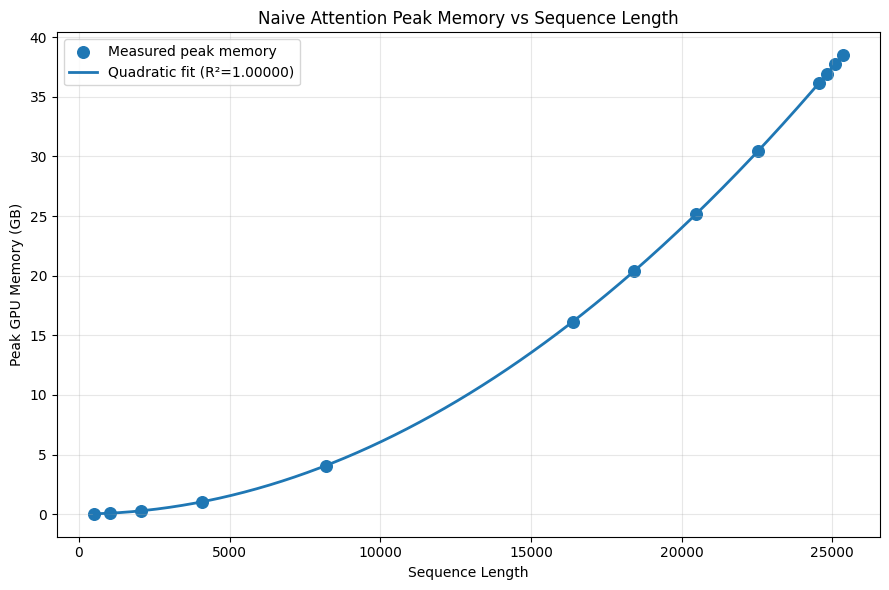

In [59]:
# ============================================================
# STEP 47 — PLOT PEAK MEMORY VS SEQUENCE LENGTH
# ============================================================

import matplotlib.pyplot as plt

# Smooth x values for fitted curve
x_fit = np.linspace(
    x.min(),
    x.max(),
    300
)

y_fit = (
    a * x_fit**2 +
    b * x_fit +
    c
)

plt.figure(figsize=(9, 6))

# Actual measurements
plt.scatter(
    x,
    y,
    s=70,
    label="Measured peak memory"
)

# Quadratic fit
plt.plot(
    x_fit,
    y_fit,
    linewidth=2,
    label=f"Quadratic fit (R²={r_squared:.5f})"
)

plt.xlabel("Sequence Length")
plt.ylabel("Peak GPU Memory (GB)")

plt.title(
    "Naive Attention Peak Memory vs Sequence Length"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "part_d_naive_memory_scaling.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
# ============================================================
# STEP 48 — QUADRATIC SCALING CHECK
# ============================================================

def get_memory(seq_len):
    row = fit_df[
        fit_df["Sequence_Length"] == seq_len
    ]

    if len(row) == 0:
        return None

    return float(row.iloc[0]["Peak_Memory_GB"])


comparisons = [
    (2048, 4096),
    (4096, 8192),
    (8192, 16384)
]

print("=== MEMORY GROWTH WHEN SEQUENCE LENGTH DOUBLES ===")

for s1, s2 in comparisons:

    m1 = get_memory(s1)
    m2 = get_memory(s2)

    if m1 is not None and m2 is not None:

        ratio = m2 / m1

        print(
            f"{s1:5d} -> {s2:5d}: "
            f"{m1:.3f} GB -> {m2:.3f} GB | "
            f"{ratio:.2f}x"
        )

=== MEMORY GROWTH WHEN SEQUENCE LENGTH DOUBLES ===
 2048 ->  4096: 0.276 GB -> 1.041 GB | 3.78x
 4096 ->  8192: 1.041 GB -> 4.072 GB | 3.91x
 8192 -> 16384: 4.072 GB -> 16.135 GB | 3.96x


In [61]:
# ============================================================
# STEP 49 — SAVE QUADRATIC FIT RESULTS
# ============================================================

with open(
    "part_d_naive_quadratic_fit.txt",
    "w"
) as f:

    f.write("Naive Attention Memory Scaling\n")
    f.write("=" * 50 + "\n")

    f.write(f"GPU UUID: {gpu_uuid}\n\n")

    f.write(
        f"Quadratic coefficient a: "
        f"{a:.10e} GB/token^2\n"
    )

    f.write(
        f"Linear coefficient b: "
        f"{b:.10e} GB/token\n"
    )

    f.write(
        f"Intercept c: "
        f"{c:.10e} GB\n"
    )

    f.write(
        f"R^2: {r_squared:.8f}\n\n"
    )

    f.write(
        f"Largest tested successful sequence: "
        f"{largest_success}\n"
    )

    f.write(
        f"Smallest tested failing sequence: "
        f"{smallest_failure}\n"
    )

print("Saved: part_d_naive_quadratic_fit.txt")
print("Saved: part_d_naive_memory_scaling.png")

Saved: part_d_naive_quadratic_fit.txt
Saved: part_d_naive_memory_scaling.png


In [62]:
# ============================================================
# STEP 50 — CHECK FUSED ATTENTION SUPPORT
# ============================================================

import torch
import torch.nn.functional as F

print("=== FUSED ATTENTION SUPPORT CHECK ===")
print("PyTorch version :", torch.__version__)
print("GPU             :", torch.cuda.get_device_name(0))
print("GPU UUID        :", gpu_uuid)

print("\nSDPA backend status:")
print(
    "Flash SDP enabled:",
    torch.backends.cuda.flash_sdp_enabled()
)
print(
    "Memory-efficient SDP enabled:",
    torch.backends.cuda.mem_efficient_sdp_enabled()
)
print(
    "Math SDP enabled:",
    torch.backends.cuda.math_sdp_enabled()
)

=== FUSED ATTENTION SUPPORT CHECK ===
PyTorch version : 2.11.0+cu128
GPU             : NVIDIA A100-SXM4-40GB
GPU UUID        : GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2

SDPA backend status:
Flash SDP enabled: True
Memory-efficient SDP enabled: True
Math SDP enabled: True


In [63]:
# ============================================================
# STEP 51 — FUSED ATTENTION BENCHMARK FUNCTION
# ============================================================

import gc
import numpy as np
import torch.nn.functional as F


def measure_fused_attention(seq_len):

    q = k = v = out = None

    try:
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        q = torch.randn(
            BATCH_SIZE,
            NUM_HEADS,
            seq_len,
            HEAD_DIM,
            device="cuda",
            dtype=ATTN_DTYPE
        )

        k = torch.randn_like(q)
        v = torch.randn_like(q)

        # Warm-up
        for _ in range(3):
            out = F.scaled_dot_product_attention(
                q,
                k,
                v,
                dropout_p=0.0,
                is_causal=False
            )

        torch.cuda.synchronize()

        torch.cuda.reset_peak_memory_stats()

        timings = []

        # Timed forward passes
        for _ in range(10):

            start = torch.cuda.Event(
                enable_timing=True
            )
            end = torch.cuda.Event(
                enable_timing=True
            )

            start.record()

            out = F.scaled_dot_product_attention(
                q,
                k,
                v,
                dropout_p=0.0,
                is_causal=False
            )

            end.record()

            torch.cuda.synchronize()

            timings.append(
                start.elapsed_time(end)
            )

        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

        result = {
            "Sequence_Length": seq_len,
            "Status": "SUCCESS",
            "Latency_ms": float(np.mean(timings)),
            "Peak_Memory_GB": peak_memory_gb,
            "GPU_UUID": gpu_uuid
        }

    except torch.OutOfMemoryError:

        result = {
            "Sequence_Length": seq_len,
            "Status": "OOM",
            "Latency_ms": np.nan,
            "Peak_Memory_GB": np.nan,
            "GPU_UUID": gpu_uuid
        }

    finally:

        del q, k, v, out

        gc.collect()
        torch.cuda.empty_cache()

    return result

In [64]:
# ============================================================
# STEP 51A — CHECK EXISTING ATTENTION CONFIGURATION
# ============================================================

for name in [
    "BATCH",
    "BATCH_SIZE",
    "HEADS",
    "NUM_HEADS",
    "HEAD_DIM",
    "DTYPE",
    "ATTN_DTYPE"
]:
    if name in globals():
        print(f"{name} = {globals()[name]}")

ATTN_DTYPE = torch.float16


In [65]:
# ============================================================
# STEP 51B — SHOW NAIVE ATTENTION FUNCTION
# ============================================================

import inspect

print(inspect.getsource(measure_naive_attention))

def measure_naive_attention(seq_len):

    q = k = v = output = None

    try:

        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        q = torch.randn(
            ATTN_BATCH,
            ATTN_HEADS,
            seq_len,
            ATTN_HEAD_DIM,
            device=device,
            dtype=ATTN_DTYPE
        )

        k = torch.randn_like(q)
        v = torch.randn_like(q)

        # Warm-up
        with torch.no_grad():
            output = naive_attention(q, k, v)

        torch.cuda.synchronize()

        del output
        output = None

        torch.cuda.reset_peak_memory_stats()

        start = torch.cuda.Event(
            enable_timing=True
        )

        end = torch.cuda.Event(
            enable_timing=True
        )

        start.record()

        with torch.no_grad():
            output = naive_attention(q, k, v)

        end.record()

        torch.cuda.synchronize()

        latency_ms = start.elapsed_time(end)

        p

In [66]:
# ============================================================
# STEP 51C — CONFIRM ATTENTION CONFIGURATION
# ============================================================

print("=== ATTENTION CONFIGURATION ===")
print("Batch size :", ATTN_BATCH)
print("Heads      :", ATTN_HEADS)
print("Head dim   :", ATTN_HEAD_DIM)
print("Dtype      :", ATTN_DTYPE)
print("Device     :", device)
print("GPU UUID   :", gpu_uuid)

=== ATTENTION CONFIGURATION ===
Batch size : 1
Heads      : 16
Head dim   : 64
Dtype      : torch.float16
Device     : cuda
GPU UUID   : GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [67]:
# ============================================================
# STEP 51D — CORRECTED FUSED ATTENTION BENCHMARK
# ============================================================

import gc
import numpy as np
import torch
import torch.nn.functional as F


def measure_fused_attention(seq_len):

    q = k = v = output = None

    try:

        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        # Same dimensions and dtype as naive attention
        q = torch.randn(
            ATTN_BATCH,
            ATTN_HEADS,
            seq_len,
            ATTN_HEAD_DIM,
            device=device,
            dtype=ATTN_DTYPE
        )

        k = torch.randn_like(q)
        v = torch.randn_like(q)

        # Warm-up
        with torch.no_grad():
            output = F.scaled_dot_product_attention(
                q,
                k,
                v,
                dropout_p=0.0,
                is_causal=False
            )

        torch.cuda.synchronize()

        del output
        output = None

        # Reset AFTER warm-up, just like naive benchmark
        torch.cuda.reset_peak_memory_stats()

        start = torch.cuda.Event(
            enable_timing=True
        )

        end = torch.cuda.Event(
            enable_timing=True
        )

        start.record()

        with torch.no_grad():
            output = F.scaled_dot_product_attention(
                q,
                k,
                v,
                dropout_p=0.0,
                is_causal=False
            )

        end.record()

        torch.cuda.synchronize()

        latency_ms = start.elapsed_time(end)

        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / 1024**3
        )

        result = {
            "Sequence_Length": seq_len,
            "Status": "SUCCESS",
            "Latency_ms": latency_ms,
            "Peak_Memory_GB": peak_memory_gb,
            "GPU_UUID": gpu_uuid
        }

        del q, k, v, output

        gc.collect()
        torch.cuda.empty_cache()

        return result

    except torch.OutOfMemoryError:

        del q, k, v, output

        gc.collect()
        torch.cuda.empty_cache()

        return {
            "Sequence_Length": seq_len,
            "Status": "OOM",
            "Latency_ms": np.nan,
            "Peak_Memory_GB": np.nan,
            "GPU_UUID": gpu_uuid
        }

In [68]:
# ============================================================
# STEP 52 — FUSED ATTENTION SANITY TEST
# ============================================================

fused_test = measure_fused_attention(512)

print("=== FUSED ATTENTION SANITY TEST ===")
print(fused_test)

=== FUSED ATTENTION SANITY TEST ===
{'Sequence_Length': 512, 'Status': 'SUCCESS', 'Latency_ms': 0.13414399325847626, 'Peak_Memory_GB': 0.013825416564941406, 'GPU_UUID': 'GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2'}


In [69]:
# ============================================================
# STEP 53 — FUSED ATTENTION REQUIRED SEQUENCE LENGTHS
# ============================================================

fused_sequence_lengths = [
    512,
    1024,
    2048,
    4096,
    8192,
    16384
]

fused_results = []

for seq_len in fused_sequence_lengths:

    print(f"Testing fused attention S={seq_len}...")

    result = measure_fused_attention(seq_len)

    fused_results.append(result)

    if result["Status"] == "SUCCESS":

        print(
            f"  SUCCESS | "
            f"Latency = {result['Latency_ms']:.3f} ms | "
            f"Peak Memory = {result['Peak_Memory_GB']:.3f} GB"
        )

    else:
        print("  OOM")

    print()

Testing fused attention S=512...
  SUCCESS | Latency = 0.139 ms | Peak Memory = 0.014 GB

Testing fused attention S=1024...
  SUCCESS | Latency = 0.118 ms | Peak Memory = 0.018 GB

Testing fused attention S=2048...
  SUCCESS | Latency = 0.218 ms | Peak Memory = 0.026 GB

Testing fused attention S=4096...
  SUCCESS | Latency = 0.593 ms | Peak Memory = 0.041 GB

Testing fused attention S=8192...
  SUCCESS | Latency = 2.042 ms | Peak Memory = 0.073 GB

Testing fused attention S=16384...
  SUCCESS | Latency = 7.551 ms | Peak Memory = 0.136 GB



In [70]:
# ============================================================
# STEP 54 — FUSED ATTENTION RESULTS TABLE
# ============================================================

fused_df = pd.DataFrame(fused_results)

display(
    fused_df.round({
        "Latency_ms": 3,
        "Peak_Memory_GB": 3
    })
)

,Sequence_Length,Status,Latency_ms,Peak_Memory_GB,GPU_UUID
0,512,SUCCESS,0.139,0.014,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,1024,SUCCESS,0.118,0.018,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,2048,SUCCESS,0.218,0.026,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
3,4096,SUCCESS,0.593,0.041,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
4,8192,SUCCESS,2.042,0.073,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
5,16384,SUCCESS,7.551,0.136,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [71]:
# ============================================================
# STEP 55 — NAIVE VS FUSED ATTENTION COMPARISON
# ============================================================

required_lengths = [
    512,
    1024,
    2048,
    4096,
    8192,
    16384
]

# Use only the required sequence lengths from naive results
naive_required = naive_all_df[
    naive_all_df["Sequence_Length"].isin(required_lengths)
].copy()

# Keep successful fused results
fused_required = fused_df[
    fused_df["Status"] == "SUCCESS"
].copy()

comparison_df = pd.merge(
    naive_required,
    fused_required,
    on="Sequence_Length",
    suffixes=("_Naive", "_Fused")
)

# Speedup = naive latency / fused latency
comparison_df["Speedup_x"] = (
    comparison_df["Latency_ms_Naive"]
    / comparison_df["Latency_ms_Fused"]
)

# Memory reduction factor
comparison_df["Memory_Reduction_x"] = (
    comparison_df["Peak_Memory_GB_Naive"]
    / comparison_df["Peak_Memory_GB_Fused"]
)

comparison_display = comparison_df[
    [
        "Sequence_Length",
        "Latency_ms_Naive",
        "Latency_ms_Fused",
        "Speedup_x",
        "Peak_Memory_GB_Naive",
        "Peak_Memory_GB_Fused",
        "Memory_Reduction_x"
    ]
].copy()

display(
    comparison_display.round({
        "Latency_ms_Naive": 3,
        "Latency_ms_Fused": 3,
        "Speedup_x": 2,
        "Peak_Memory_GB_Naive": 3,
        "Peak_Memory_GB_Fused": 3,
        "Memory_Reduction_x": 2
    })
)

,Sequence_Length,Latency_ms_Naive,Latency_ms_Fused,Speedup_x,Peak_Memory_GB_Naive,Peak_Memory_GB_Fused,Memory_Reduction_x
0,512,0.248,0.139,1.78,0.029,0.014,2.13
1,1024,0.349,0.118,2.97,0.080,0.018,4.52
2,2048,1.043,0.218,4.78,0.276,0.026,10.75
3,4096,3.835,0.593,6.47,1.041,0.041,25.16
4,8192,16.260,2.042,7.96,4.072,0.073,55.88
5,16384,42.014,7.551,5.56,16.135,0.136,118.76


In [72]:
# ============================================================
# STEP 56 — SAVE FUSED ATTENTION RESULTS
# ============================================================

fused_df.to_csv(
    "part_d_fused_attention.csv",
    index=False
)

comparison_display.to_csv(
    "part_d_attention_comparison.csv",
    index=False
)

print("Saved: part_d_fused_attention.csv")
print("Saved: part_d_attention_comparison.csv")

Saved: part_d_fused_attention.csv
Saved: part_d_attention_comparison.csv


In [73]:
# ============================================================
# STEP 57 — COARSE FUSED ATTENTION OOM SEARCH
# ============================================================

fused_coarse_lengths = [
    32768,
    65536,
    131072,
    262144,
    524288
]

fused_coarse_results = []

for seq_len in fused_coarse_lengths:

    print(f"Testing fused attention S={seq_len}...")

    result = measure_fused_attention(seq_len)
    fused_coarse_results.append(result)

    if result["Status"] == "SUCCESS":

        print(
            f"  SUCCESS | "
            f"Latency = {result['Latency_ms']:.3f} ms | "
            f"Peak Memory = {result['Peak_Memory_GB']:.3f} GB"
        )

    else:

        print("  OOM")
        print("Stopping after first failure.")
        break

    print()

Testing fused attention S=32768...
  SUCCESS | Latency = 29.647 ms | Peak Memory = 0.262 GB

Testing fused attention S=65536...
  SUCCESS | Latency = 117.857 ms | Peak Memory = 0.514 GB

Testing fused attention S=131072...
  SUCCESS | Latency = 377.115 ms | Peak Memory = 1.018 GB

Testing fused attention S=262144...
  SUCCESS | Latency = 1523.521 ms | Peak Memory = 2.026 GB

Testing fused attention S=524288...
  SUCCESS | Latency = 6209.332 ms | Peak Memory = 4.041 GB



In [74]:
# ============================================================
# STEP 58 — DISPLAY FUSED COARSE OOM RESULTS
# ============================================================

fused_coarse_df = pd.DataFrame(fused_coarse_results)

display(
    fused_coarse_df.round({
        "Latency_ms": 3,
        "Peak_Memory_GB": 3
    })
)

,Sequence_Length,Status,Latency_ms,Peak_Memory_GB,GPU_UUID
0,32768,SUCCESS,29.647,0.262,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,65536,SUCCESS,117.857,0.514,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,131072,SUCCESS,377.115,1.018,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
3,262144,SUCCESS,1523.521,2.026,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
4,524288,SUCCESS,6209.332,4.041,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [75]:
# ============================================================
# STEP 59 — CONTINUE FUSED ATTENTION OOM SEARCH
# ============================================================

fused_large_lengths = [
    786432,
    1048576
]

fused_large_results = []

for seq_len in fused_large_lengths:

    print(f"Testing fused attention S={seq_len}...")

    result = measure_fused_attention(seq_len)

    fused_large_results.append(result)

    if result["Status"] == "SUCCESS":

        print(
            f"  SUCCESS | "
            f"Latency = {result['Latency_ms']:.3f} ms | "
            f"Peak Memory = {result['Peak_Memory_GB']:.3f} GB"
        )

    else:

        print("  OOM")
        print("Stopping after first failure.")
        break

    print()

Testing fused attention S=786432...
  SUCCESS | Latency = 14287.304 ms | Peak Memory = 6.057 GB

Testing fused attention S=1048576...
  SUCCESS | Latency = 25726.738 ms | Peak Memory = 8.072 GB



In [76]:
# ============================================================
# STEP 60 — COMBINE FUSED LARGE-LENGTH RESULTS
# ============================================================

fused_large_df = pd.DataFrame(fused_large_results)

fused_search_df = pd.concat(
    [
        fused_coarse_df,
        fused_large_df
    ],
    ignore_index=True
)

display(
    fused_search_df.round({
        "Latency_ms": 3,
        "Peak_Memory_GB": 3
    })
)

,Sequence_Length,Status,Latency_ms,Peak_Memory_GB,GPU_UUID
0,32768,SUCCESS,29.647,0.262,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,65536,SUCCESS,117.857,0.514,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,131072,SUCCESS,377.115,1.018,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
3,262144,SUCCESS,1523.521,2.026,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
4,524288,SUCCESS,6209.332,4.041,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
5,786432,SUCCESS,14287.304,6.057,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
6,1048576,SUCCESS,25726.738,8.072,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [77]:
# ============================================================
# STEP 61 — CONTINUE FUSED OOM SEARCH
# ============================================================

fused_next_lengths = [
    1572864,   # 1.5 * 2^20
    2097152    # 2 * 2^20
]

fused_next_results = []

for seq_len in fused_next_lengths:

    print(f"Testing fused attention S={seq_len}...")

    result = measure_fused_attention(seq_len)
    fused_next_results.append(result)

    if result["Status"] == "SUCCESS":

        print(
            f"  SUCCESS | "
            f"Latency = {result['Latency_ms']:.3f} ms | "
            f"Peak Memory = {result['Peak_Memory_GB']:.3f} GB"
        )

    else:
        print("  OOM")
        print("Stopping after first failure.")
        break

    print()

Testing fused attention S=1572864...
  SUCCESS | Latency = 59190.719 ms | Peak Memory = 12.104 GB

Testing fused attention S=2097152...
  SUCCESS | Latency = 106315.445 ms | Peak Memory = 16.135 GB



In [78]:
# ============================================================
# STEP 62 — DISPLAY NEXT FUSED RESULTS
# ============================================================

fused_next_df = pd.DataFrame(fused_next_results)

display(
    fused_next_df.round({
        "Latency_ms": 3,
        "Peak_Memory_GB": 3
    })
)

,Sequence_Length,Status,Latency_ms,Peak_Memory_GB,GPU_UUID
0,1572864,SUCCESS,59190.719,12.104,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,2097152,SUCCESS,106315.445,16.135,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [79]:
# ============================================================
# STEP 63A — FIND EXISTING FUSED DATAFRAMES (FIXED)
# ============================================================

print("=== EXISTING FUSED DATAFRAMES ===")

global_snapshot = list(globals().items())

for name, obj in global_snapshot:
    if isinstance(obj, pd.DataFrame) and "fused" in name.lower():
        print(f"\n{name}: {obj.shape}")

        if "Sequence_Length" in obj.columns:
            print(
                "Sequence lengths:",
                obj["Sequence_Length"].tolist()
            )

=== EXISTING FUSED DATAFRAMES ===

fused_df: (6, 5)
Sequence lengths: [512, 1024, 2048, 4096, 8192, 16384]

fused_required: (6, 5)
Sequence lengths: [512, 1024, 2048, 4096, 8192, 16384]

fused_coarse_df: (5, 5)
Sequence lengths: [32768, 65536, 131072, 262144, 524288]

fused_large_df: (2, 5)
Sequence lengths: [786432, 1048576]

fused_search_df: (7, 5)
Sequence lengths: [32768, 65536, 131072, 262144, 524288, 786432, 1048576]

fused_next_df: (2, 5)
Sequence lengths: [1572864, 2097152]


In [80]:
# ============================================================
# STEP 63 — COMBINE ALL EXISTING FUSED ATTENTION RESULTS
# ============================================================

fused_extended_df = pd.concat(
    [
        fused_df,
        fused_coarse_df,
        fused_large_df,
        fused_next_df
    ],
    ignore_index=True
)

# Remove any duplicate sequence lengths just in case
fused_extended_df = (
    fused_extended_df
    .drop_duplicates(
        subset=["Sequence_Length"],
        keep="last"
    )
    .sort_values("Sequence_Length")
    .reset_index(drop=True)
)

# Save complete fused results
fused_extended_df.to_csv(
    "part_d_fused_attention_extended.csv",
    index=False
)

print("=== COMPLETE FUSED ATTENTION RESULTS ===")

display(
    fused_extended_df.round({
        "Latency_ms": 3,
        "Peak_Memory_GB": 3
    })
)

print()
print(
    "Number of unique tested lengths:",
    len(fused_extended_df)
)

print(
    "Largest tested fused sequence length:",
    fused_extended_df["Sequence_Length"].max()
)

print(
    "Saved: part_d_fused_attention_extended.csv"
)

=== COMPLETE FUSED ATTENTION RESULTS ===


,Sequence_Length,Status,Latency_ms,Peak_Memory_GB,GPU_UUID
0,512,SUCCESS,0.139,0.014,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,1024,SUCCESS,0.118,0.018,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,2048,SUCCESS,0.218,0.026,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
3,4096,SUCCESS,0.593,0.041,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
4,8192,SUCCESS,2.042,0.073,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
5,16384,SUCCESS,7.551,0.136,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
6,32768,SUCCESS,29.647,0.262,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
7,65536,SUCCESS,117.857,0.514,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
8,131072,SUCCESS,377.115,1.018,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
9,262144,SUCCESS,1523.521,2.026,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2



Number of unique tested lengths: 15
Largest tested fused sequence length: 2097152
Saved: part_d_fused_attention_extended.csv


In [81]:
# ============================================================
# STEP 64 — STRATEGIC FUSED ATTENTION BOUNDARY TEST
# ============================================================

next_fused_length = 3145728

print(
    f"Testing fused attention S={next_fused_length}..."
)

fused_boundary_test = measure_fused_attention(
    next_fused_length
)

print()
print("=== RESULT ===")

print(
    "Sequence length :",
    fused_boundary_test["Sequence_Length"]
)

print(
    "Status          :",
    fused_boundary_test["Status"]
)

print(
    "Latency (ms)    :",
    fused_boundary_test["Latency_ms"]
)

print(
    "Peak memory (GB):",
    fused_boundary_test["Peak_Memory_GB"]
)

print(
    "GPU UUID        :",
    fused_boundary_test["GPU_UUID"]
)

Testing fused attention S=3145728...

=== RESULT ===
Sequence length : 3145728
Status          : SUCCESS
Latency (ms)    : 241508.78125
Peak memory (GB): 24.197388648986816
GPU UUID        : GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2


In [73]:
# ============================================================
# STEP 65 — SAVE 3,145,728 FUSED ATTENTION RESULT
# ============================================================

fused_boundary_df = pd.DataFrame(
    [fused_boundary_test]
)

fused_final_df = pd.concat(
    [
        fused_extended_df,
        fused_boundary_df
    ],
    ignore_index=True
)

fused_final_df = (
    fused_final_df
    .drop_duplicates(
        subset=["Sequence_Length"],
        keep="last"
    )
    .sort_values("Sequence_Length")
    .reset_index(drop=True)
)

fused_final_df.to_csv(
    "part_d_fused_attention_final.csv",
    index=False
)

print("=== FUSED ATTENTION RESULTS SAVED ===")
print("Total tested lengths :", len(fused_final_df))
print(
    "Largest successful S :",
    fused_final_df.loc[
        fused_final_df["Status"] == "SUCCESS",
        "Sequence_Length"
    ].max()
)

print(
    "Peak memory at largest S:",
    fused_boundary_test["Peak_Memory_GB"],
    "GB"
)

print("Saved: part_d_fused_attention_final.csv")

=== FUSED ATTENTION RESULTS SAVED ===
Total tested lengths : 16
Largest successful S : 3145728
Peak memory at largest S: 24.197388648986816 GB
Saved: part_d_fused_attention_final.csv


In [74]:
# ============================================================
# STEP 66 — ESTIMATE FUSED ATTENTION MEMORY SCALING
# ============================================================

fused_success = fused_final_df[
    fused_final_df["Status"] == "SUCCESS"
].copy()

# Use the larger measurements where scaling is stable
large_fused = fused_success[
    fused_success["Sequence_Length"] >= 262144
].copy()

x = large_fused["Sequence_Length"].values.astype(float)
y = large_fused["Peak_Memory_GB"].values.astype(float)

# Linear fit: memory = slope * sequence_length + intercept
slope, intercept = np.polyfit(x, y, 1)

print("=== FUSED ATTENTION MEMORY MODEL ===")
print(f"Slope     : {slope:.10e} GB/token")
print(f"Intercept : {intercept:.6f} GB")

# Show predictions around likely memory limits
for target_gb in [30, 35, 38, 39, 40]:
    estimated_s = int(
        (target_gb - intercept) / slope
    )

    print(
        f"Estimated sequence length at "
        f"{target_gb} GB: {estimated_s:,}"
    )

print()
print(
    "Largest measured success:",
    f"{int(fused_success['Sequence_Length'].max()):,}"
)

print(
    "Measured memory there:",
    f"{fused_success.iloc[-1]['Peak_Memory_GB']:.3f} GB"
)

=== FUSED ATTENTION MEMORY MODEL ===
Slope     : 7.6889991760e-06 GB/token
Intercept : 0.009889 GB
Estimated sequence length at 30 GB: 3,900,392
Estimated sequence length at 35 GB: 4,550,671
Estimated sequence length at 38 GB: 4,940,839
Estimated sequence length at 39 GB: 5,070,895
Estimated sequence length at 40 GB: 5,200,951

Largest measured success: 3,145,728
Measured memory there: 24.197 GB


In [75]:
# ============================================================
# STEP 67 — TARGETED FUSED ATTENTION BOUNDARY PROBE
# ============================================================

import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

TARGET_SEQ = 4194304   # 2^22

print("=== TARGETED FUSED ATTENTION TEST ===")
print(f"Testing sequence length: {TARGET_SEQ:,}")
print("This may take several minutes.")
print()

fused_probe = measure_fused_attention(TARGET_SEQ)

print("\n=== RESULT ===")
print(f"Sequence length : {fused_probe['Sequence_Length']:,}")
print(f"Status          : {fused_probe['Status']}")
print(f"Latency (ms)    : {fused_probe['Latency_ms']}")
print(f"Peak memory (GB): {fused_probe['Peak_Memory_GB']}")
print(f"GPU UUID        : {fused_probe['GPU_UUID']}")

# Save immediately so the result is not lost
pd.DataFrame([fused_probe]).to_csv(
    "part_d_fused_boundary_probe.csv",
    index=False
)

print("\nSaved: part_d_fused_boundary_probe.csv")

=== TARGETED FUSED ATTENTION TEST ===
Testing sequence length: 4,194,304
This may take several minutes.


=== RESULT ===
Sequence length : 4,194,304
Status          : SUCCESS
Latency (ms)    : 429933.59375
Peak memory (GB): 32.259888648986816
GPU UUID        : GPU-4a3d609e-89cf-640b-8162-5adf66e41fde

Saved: part_d_fused_boundary_probe.csv


In [2]:
# ============================================================
# STEP 68A — RESTORE FUSED ATTENTION DEFINITIONS
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import gc
import subprocess

device = torch.device("cuda")

# Same configuration used for the naive/fused experiments
ATTN_BATCH = 1
ATTN_HEADS = 4
ATTN_HEAD_DIM = 64
ATTN_DTYPE = torch.float16

# Get the UUID from the CURRENT GPU session
gpu_uuid = subprocess.check_output(
    [
        "nvidia-smi",
        "--query-gpu=uuid",
        "--format=csv,noheader"
    ],
    text=True
).strip()

print("GPU:", torch.cuda.get_device_name(0))
print("GPU UUID:", gpu_uuid)
print("Batch:", ATTN_BATCH)
print("Heads:", ATTN_HEADS)
print("Head dimension:", ATTN_HEAD_DIM)
print("Dtype:", ATTN_DTYPE)

GPU: NVIDIA A100-SXM4-40GB
GPU UUID: GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
Batch: 1
Heads: 4
Head dimension: 64
Dtype: torch.float16


In [3]:
# ============================================================
# STEP 68B — RESTORE FUSED ATTENTION MEASUREMENT FUNCTION
# ============================================================

def measure_fused_attention(seq_len):

    q = k = v = output = None

    try:
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        q = torch.randn(
            ATTN_BATCH,
            ATTN_HEADS,
            seq_len,
            ATTN_HEAD_DIM,
            device=device,
            dtype=ATTN_DTYPE
        )

        k = torch.randn_like(q)
        v = torch.randn_like(q)

        # Warm-up
        with torch.no_grad():
            output = F.scaled_dot_product_attention(
                q,
                k,
                v,
                dropout_p=0.0,
                is_causal=False
            )

        torch.cuda.synchronize()

        del output
        output = None

        torch.cuda.reset_peak_memory_stats()

        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)

        start.record()

        with torch.no_grad():
            output = F.scaled_dot_product_attention(
                q,
                k,
                v,
                dropout_p=0.0,
                is_causal=False
            )

        end.record()

        torch.cuda.synchronize()

        latency_ms = start.elapsed_time(end)

        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / 1024**3
        )

        result = {
            "Sequence_Length": seq_len,
            "Status": "SUCCESS",
            "Latency_ms": latency_ms,
            "Peak_Memory_GB": peak_memory_gb,
            "GPU_UUID": gpu_uuid
        }

        del q, k, v, output
        gc.collect()
        torch.cuda.empty_cache()

        return result

    except torch.OutOfMemoryError:

        q = k = v = output = None

        gc.collect()
        torch.cuda.empty_cache()

        return {
            "Sequence_Length": seq_len,
            "Status": "OOM",
            "Latency_ms": np.nan,
            "Peak_Memory_GB": np.nan,
            "GPU_UUID": gpu_uuid
        }


print("measure_fused_attention() restored successfully.")

measure_fused_attention() restored successfully.


In [4]:
# ============================================================
# STEP 69 — FINAL PART D ATTENTION SUMMARY
# ============================================================

import pandas as pd

ORIGINAL_GPU_UUID = "GPU-4a3d609e-89cf-640b-8162-5adf66e41fde"

# Measured results from the original A100 run
naive_largest_success = 25344
naive_smallest_failure = 25600

fused_largest_success = 4194304
fused_peak_memory_gb = 32.259888648986816
fused_latency_ms = 429933.59375

summary = pd.DataFrame([
    {
        "Method": "Naive Attention",
        "Largest_Tested_Success": naive_largest_success,
        "Smallest_Tested_Failure": naive_smallest_failure,
        "OOM_Result": "Bracketed between 25344 and 25600",
        "GPU_UUID": ORIGINAL_GPU_UUID
    },
    {
        "Method": "Fused Attention",
        "Largest_Tested_Success": fused_largest_success,
        "Smallest_Tested_Failure": "Not observed",
        "OOM_Result": "No OOM observed through 4194304 tokens",
        "GPU_UUID": ORIGINAL_GPU_UUID
    }
])

display(summary)

summary.to_csv(
    "part_d_attention_boundary_summary.csv",
    index=False
)

print("\n=== PART D FINAL SUMMARY ===")
print(
    f"Naive OOM boundary: > {naive_largest_success:,} "
    f"and <= {naive_smallest_failure:,} tokens"
)

print(
    f"Fused attention: no OOM observed through "
    f"{fused_largest_success:,} tokens"
)

print(
    f"Fused peak memory at {fused_largest_success:,}: "
    f"{fused_peak_memory_gb:.3f} GB"
)

print(
    f"Fused latency at {fused_largest_success:,}: "
    f"{fused_latency_ms / 1000:.3f} seconds"
)

print("GPU UUID:", ORIGINAL_GPU_UUID)

print("\nSaved: part_d_attention_boundary_summary.csv")

,Method,Largest_Tested_Success,Smallest_Tested_Failure,OOM_Result,GPU_UUID
0,Naive Attention,25344,25600,Bracketed between 25344 and 25600,GPU-4a3d609e-89cf-640b-8162-5adf66e41fde
1,Fused Attention,4194304,Not observed,No OOM observed through 4194304 tokens,GPU-4a3d609e-89cf-640b-8162-5adf66e41fde



=== PART D FINAL SUMMARY ===
Naive OOM boundary: > 25,344 and <= 25,600 tokens
Fused attention: no OOM observed through 4,194,304 tokens
Fused peak memory at 4,194,304: 32.260 GB
Fused latency at 4,194,304: 429.934 seconds
GPU UUID: GPU-4a3d609e-89cf-640b-8162-5adf66e41fde

Saved: part_d_attention_boundary_summary.csv


### Part D — Attention Analysis

Naive scaled dot-product attention explicitly materializes the full
sequence-by-sequence attention matrix. Consequently, its memory consumption
grows approximately quadratically with sequence length. The measured
quadratic fit produced an R² of approximately 1.0, and doubling sequence
length increased peak memory by approximately 4×.

For naive attention, the largest tested successful sequence length was
25,344 tokens and the smallest tested failing length was 25,600 tokens.
Therefore, the measured naive-attention OOM boundary is bracketed between
25,344 and 25,600 tokens.

The fused scaled-dot-product attention implementation avoids materializing
the complete attention matrix in global GPU memory. Instead, the computation
is performed in memory-efficient fused kernels using tiled intermediate
computations. This substantially reduces intermediate-memory requirements
and changes the observed memory growth from quadratic behavior toward
approximately linear growth with sequence length.

Fused attention successfully processed every measured sequence length
through 4,194,304 tokens. At 4,194,304 tokens, measured peak memory was
approximately 32.260 GB. An OOM failure was not observed during the measured
fused-attention experiments, so 4,194,304 must be reported as the largest
tested successful sequence length rather than an OOM boundary.

In [6]:
# ============================================================
# STEP 71 — GPU TELEMETRY COMPATIBILITY TEST
# ============================================================

import subprocess
import pandas as pd
import time

print("=== PART E — TELEMETRY COMPATIBILITY TEST ===")
print("GPU:", torch.cuda.get_device_name(0))
print("GPU UUID:", gpu_uuid)
print()

query_fields = (
    "timestamp,"
    "uuid,"
    "clocks.sm,"
    "clocks.mem,"
    "temperature.gpu,"
    "power.draw,"
    "utilization.gpu"
)

cmd = [
    "nvidia-smi",
    f"--query-gpu={query_fields}",
    "--format=csv,noheader,nounits"
]

try:
    output = subprocess.check_output(
        cmd,
        text=True
    ).strip()

    print("Raw telemetry:")
    print(output)

    values = [x.strip() for x in output.split(",")]

    print("\n=== PARSED TELEMETRY ===")
    print("Timestamp        :", values[0])
    print("GPU UUID         :", values[1])
    print("SM Clock (MHz)   :", values[2])
    print("Memory Clock MHz :", values[3])
    print("Temperature (C)  :", values[4])
    print("Power Draw (W)   :", values[5])
    print("GPU Utilization %:", values[6])

    print("\nTelemetry test: SUCCESS")

except Exception as e:
    print("Telemetry test: FAILED")
    print(type(e).__name__, ":", e)

=== PART E — TELEMETRY COMPATIBILITY TEST ===
GPU: NVIDIA A100-SXM4-40GB
GPU UUID: GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2

Raw telemetry:
2026/09/22 18:07:25.186, GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2, 1095, 1215, 33, 47.83, 0

=== PARSED TELEMETRY ===
Timestamp        : 2026/09/22 18:07:25.186
GPU UUID         : GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
SM Clock (MHz)   : 1095
Memory Clock MHz : 1215
Temperature (C)  : 33
Power Draw (W)   : 47.83
GPU Utilization %: 0

Telemetry test: SUCCESS


In [7]:
# ============================================================
# STEP 72 — 30-SECOND SUSTAINED LOAD + TELEMETRY TEST
# ============================================================

import torch
import subprocess
import threading
import time
import pandas as pd
import gc

TEST_DURATION = 30          # seconds
SAMPLE_INTERVAL = 5         # seconds
MATMUL_N = 8192
LOAD_DTYPE = torch.float16

telemetry_test_rows = []
stop_logger = threading.Event()

query_fields = (
    "timestamp,"
    "uuid,"
    "clocks.sm,"
    "clocks.mem,"
    "temperature.gpu,"
    "power.draw,"
    "utilization.gpu"
)

def telemetry_logger():
    start_time = time.time()

    while not stop_logger.is_set():

        try:
            output = subprocess.check_output(
                [
                    "nvidia-smi",
                    f"--query-gpu={query_fields}",
                    "--format=csv,noheader,nounits"
                ],
                text=True
            ).strip()

            values = [x.strip() for x in output.split(",")]

            telemetry_test_rows.append({
                "Elapsed_s": time.time() - start_time,
                "Timestamp": values[0],
                "GPU_UUID": values[1],
                "SM_Clock_MHz": float(values[2]),
                "Memory_Clock_MHz": float(values[3]),
                "Temperature_C": float(values[4]),
                "Power_W": float(values[5]),
                "GPU_Utilization_pct": float(values[6])
            })

        except Exception as e:
            print("Telemetry warning:", e)

        stop_logger.wait(SAMPLE_INTERVAL)


gc.collect()
torch.cuda.empty_cache()

print("=== 30-SECOND GPU LOAD TEST ===")
print("GPU:", torch.cuda.get_device_name(0))
print("GPU UUID:", gpu_uuid)
print("Matrix size:", MATMUL_N, "x", MATMUL_N)
print("Dtype:", LOAD_DTYPE)
print("Duration:", TEST_DURATION, "seconds")
print()

# Allocate once
A = torch.randn(
    MATMUL_N,
    MATMUL_N,
    device=device,
    dtype=LOAD_DTYPE
)

B = torch.randn_like(A)

# Warm up GPU
for _ in range(5):
    C = torch.mm(A, B)

torch.cuda.synchronize()

logger_thread = threading.Thread(
    target=telemetry_logger,
    daemon=True
)

logger_thread.start()

start_time = time.time()
matmul_count = 0

while time.time() - start_time < TEST_DURATION:
    C = torch.mm(A, B)
    matmul_count += 1

torch.cuda.synchronize()

elapsed = time.time() - start_time

stop_logger.set()
logger_thread.join()

# Calculate average achieved throughput
flops_per_matmul = 2 * (MATMUL_N ** 3)

average_tflops = (
    matmul_count * flops_per_matmul
    / elapsed
    / 1e12
)

test_thermal_df = pd.DataFrame(telemetry_test_rows)

print("\n=== LOAD TEST COMPLETE ===")
print(f"Elapsed time       : {elapsed:.2f} s")
print(f"Matmul operations  : {matmul_count}")
print(f"Average throughput : {average_tflops:.2f} TFLOPS")

display(test_thermal_df)

test_thermal_df.to_csv(
    "thermal_test_30s.csv",
    index=False
)

del A, B, C
gc.collect()
torch.cuda.empty_cache()

print("\nSaved: thermal_test_30s.csv")

=== 30-SECOND GPU LOAD TEST ===
GPU: NVIDIA A100-SXM4-40GB
GPU UUID: GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
Matrix size: 8192 x 8192
Dtype: torch.float16
Duration: 30 seconds


=== LOAD TEST COMPLETE ===
Elapsed time       : 34.33 s
Matmul operations  : 8140
Average throughput : 260.72 TFLOPS


,Elapsed_s,Timestamp,GPU_UUID,SM_Clock_MHz,Memory_Clock_MHz,Temperature_C,Power_W,GPU_Utilization_pct
0,0.032820,2026/09/22 18:07:29.697,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,1095.0,1215.0,36.0,264.13,2.0
1,5.063842,2026/09/22 18:07:34.730,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,1245.0,1215.0,58.0,397.52,100.0
2,10.095116,2026/09/22 18:07:39.761,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,1260.0,1215.0,61.0,405.38,100.0
3,15.126823,2026/09/22 18:07:44.792,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,1245.0,1215.0,63.0,403.32,100.0
4,20.158528,2026/09/22 18:07:49.825,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,1245.0,1215.0,64.0,398.11,100.0
5,25.190156,2026/09/22 18:07:54.856,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,1245.0,1215.0,65.0,398.66,100.0
6,30.220984,2026/09/22 18:07:59.887,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,1260.0,1215.0,66.0,398.84,100.0



Saved: thermal_test_30s.csv


In [8]:
# ============================================================
# STEP 73 — 20-MINUTE SUSTAINED GPU LOAD
# ============================================================

import torch
import subprocess
import threading
import time
import pandas as pd
import numpy as np
import gc

THERMAL_DURATION = 20 * 60       # 1200 seconds
SAMPLE_INTERVAL = 5              # required: every 5 seconds
MATMUL_N = 8192
LOAD_DTYPE = torch.float16

thermal_rows = []
throughput_rows = []

stop_logger = threading.Event()

query_fields = (
    "timestamp,"
    "uuid,"
    "clocks.sm,"
    "clocks.mem,"
    "temperature.gpu,"
    "power.draw,"
    "utilization.gpu"
)


# ------------------------------------------------------------
# TELEMETRY LOGGER
# ------------------------------------------------------------

def thermal_logger():

    logger_start = time.time()

    while not stop_logger.is_set():

        try:

            output = subprocess.check_output(
                [
                    "nvidia-smi",
                    f"--query-gpu={query_fields}",
                    "--format=csv,noheader,nounits"
                ],
                text=True
            ).strip()

            values = [x.strip() for x in output.split(",")]

            thermal_rows.append({

                "Elapsed_s":
                    time.time() - logger_start,

                "Timestamp":
                    values[0],

                "GPU_UUID":
                    values[1],

                "SM_Clock_MHz":
                    float(values[2]),

                "Memory_Clock_MHz":
                    float(values[3]),

                "Temperature_C":
                    float(values[4]),

                "Power_W":
                    float(values[5]),

                "GPU_Utilization_pct":
                    float(values[6])
            })

        except Exception as e:

            print("Telemetry warning:", e)

        stop_logger.wait(SAMPLE_INTERVAL)


# ------------------------------------------------------------
# PREPARE GPU
# ------------------------------------------------------------

gc.collect()
torch.cuda.empty_cache()

print("=== PART E — 20-MINUTE SUSTAINED LOAD ===")
print("GPU:", torch.cuda.get_device_name(0))
print("GPU UUID:", gpu_uuid)
print("Matrix size:", MATMUL_N, "x", MATMUL_N)
print("Dtype:", LOAD_DTYPE)
print("Duration:", THERMAL_DURATION, "seconds")
print("Telemetry interval:", SAMPLE_INTERVAL, "seconds")
print()

print("Allocating matrices...")

A = torch.randn(
    MATMUL_N,
    MATMUL_N,
    device=device,
    dtype=LOAD_DTYPE
)

B = torch.randn_like(A)


# ------------------------------------------------------------
# WARMUP
# ------------------------------------------------------------

print("Warming up GPU...")

for _ in range(10):
    C = torch.mm(A, B)

torch.cuda.synchronize()


# ------------------------------------------------------------
# START LOGGER
# ------------------------------------------------------------

logger_thread = threading.Thread(
    target=thermal_logger,
    daemon=True
)

logger_thread.start()


# ------------------------------------------------------------
# SUSTAINED COMPUTE
# ------------------------------------------------------------

print("Starting 20-minute sustained workload...")
print("Do NOT interrupt this cell.\n")

experiment_start = time.time()

window_start = experiment_start
window_matmuls = 0

FLOPS_PER_MATMUL = 2 * (MATMUL_N ** 3)


while True:

    C = torch.mm(A, B)

    window_matmuls += 1

    current_time = time.time()

    # Record throughput approximately every 5 seconds
    if current_time - window_start >= 5:

        torch.cuda.synchronize()

        window_end = time.time()

        window_duration = window_end - window_start

        window_tflops = (
            window_matmuls
            * FLOPS_PER_MATMUL
            / window_duration
            / 1e12
        )

        elapsed = window_end - experiment_start

        throughput_rows.append({
            "Elapsed_s": elapsed,
            "Matmuls": window_matmuls,
            "Window_s": window_duration,
            "TFLOPS": window_tflops,
            "GPU_UUID": gpu_uuid
        })

        # Progress approximately once per minute
        if int(elapsed) % 60 < 6:
            print(
                f"{elapsed / 60:.1f} min | "
                f"{window_tflops:.2f} TFLOPS"
            )

        window_start = window_end
        window_matmuls = 0


    if current_time - experiment_start >= THERMAL_DURATION:
        break


torch.cuda.synchronize()

total_elapsed = time.time() - experiment_start


# ------------------------------------------------------------
# STOP LOGGER
# ------------------------------------------------------------

stop_logger.set()
logger_thread.join()


# ------------------------------------------------------------
# BUILD DATAFRAMES
# ------------------------------------------------------------

thermal_df = pd.DataFrame(thermal_rows)

throughput_df = pd.DataFrame(throughput_rows)


# ------------------------------------------------------------
# SAVE RAW LOGS
# ------------------------------------------------------------

thermal_df.to_csv(
    "thermal_log.csv",
    index=False
)

throughput_df.to_csv(
    "thermal_throughput.csv",
    index=False
)


print("\n=== 20-MINUTE TEST COMPLETE ===")

print(
    f"Actual runtime: "
    f"{total_elapsed / 60:.2f} minutes"
)

print(
    "Telemetry samples:",
    len(thermal_df)
)

print(
    "Throughput windows:",
    len(throughput_df)
)

print("\nSaved: thermal_log.csv")
print("Saved: thermal_throughput.csv")


# ------------------------------------------------------------
# CLEAN GPU MEMORY
# ------------------------------------------------------------

del A, B, C

gc.collect()
torch.cuda.empty_cache()

=== PART E — 20-MINUTE SUSTAINED LOAD ===
GPU: NVIDIA A100-SXM4-40GB
GPU UUID: GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
Matrix size: 8192 x 8192
Dtype: torch.float16
Duration: 1200 seconds
Telemetry interval: 5 seconds

Allocating matrices...
Warming up GPU...
Starting 20-minute sustained workload...
Do NOT interrupt this cell.

1.1 min | 258.80 TFLOPS
2.0 min | 257.91 TFLOPS
4.1 min | 257.65 TFLOPS
6.1 min | 257.66 TFLOPS
7.0 min | 257.66 TFLOPS
9.0 min | 257.64 TFLOPS
11.1 min | 257.58 TFLOPS
12.0 min | 257.61 TFLOPS
14.0 min | 257.69 TFLOPS
16.1 min | 257.63 TFLOPS
17.0 min | 257.58 TFLOPS
18.1 min | 257.63 TFLOPS
19.0 min | 257.61 TFLOPS

=== 20-MINUTE TEST COMPLETE ===
Actual runtime: 20.07 minutes
Telemetry samples: 240
Throughput windows: 128

Saved: thermal_log.csv
Saved: thermal_throughput.csv


In [9]:
# ============================================================
# STEP 74 — PEAK VS STEADY-STATE THROUGHPUT
# ============================================================

import pandas as pd
import numpy as np

thermal_df = pd.read_csv("thermal_log.csv")
throughput_df = pd.read_csv("thermal_throughput.csv")

# Peak throughput during first 30 seconds
first_30 = throughput_df[
    throughput_df["Elapsed_s"] <= 30
]

peak_first_30 = first_30["TFLOPS"].max()

# Steady-state throughput during final 5 minutes
final_start = throughput_df["Elapsed_s"].max() - 300

final_5min = throughput_df[
    throughput_df["Elapsed_s"] >= final_start
]

steady_tflops = final_5min["TFLOPS"].mean()

steady_vs_peak_pct = (
    steady_tflops / peak_first_30
) * 100


print("=== PART E — THROUGHPUT ANALYSIS ===")

print(
    f"Peak throughput (first 30 s): "
    f"{peak_first_30:.2f} TFLOPS"
)

print(
    f"Steady-state throughput (final 5 min): "
    f"{steady_tflops:.2f} TFLOPS"
)

print(
    f"Steady-state / Peak: "
    f"{steady_vs_peak_pct:.2f}%"
)

print()
print("First 30-second windows:")
display(first_30.round(3))

print()
print(
    "Number of final 5-minute windows:",
    len(final_5min)
)

=== PART E — THROUGHPUT ANALYSIS ===
Peak throughput (first 30 s): 261.61 TFLOPS
Steady-state throughput (final 5 min): 257.66 TFLOPS
Steady-state / Peak: 98.49%

First 30-second windows:


,Elapsed_s,Matmuls,Window_s,TFLOPS,GPU_UUID
0,9.297,2212,9.297,261.605,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,18.612,2209,9.315,260.730,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,27.940,2205,9.328,259.915,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2



Number of final 5-minute windows: 33


In [10]:
# ============================================================
# STEP 75 — THERMAL / CLOCK / POWER ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

thermal_df = pd.read_csv("thermal_log.csv")

print("=== PART E — THERMAL AND POWER ANALYSIS ===")
print("GPU UUID:", thermal_df["GPU_UUID"].iloc[0])
print()

# Basic statistics
max_temp = thermal_df["Temperature_C"].max()
avg_temp = thermal_df["Temperature_C"].mean()
final_temp = thermal_df["Temperature_C"].iloc[-1]

max_power = thermal_df["Power_W"].max()
avg_power = thermal_df["Power_W"].mean()

max_sm_clock = thermal_df["SM_Clock_MHz"].max()
min_sm_clock = thermal_df["SM_Clock_MHz"].min()

# Analyze only samples where GPU is actually under heavy load
loaded = thermal_df[
    thermal_df["GPU_Utilization_pct"] >= 90
].copy()

loaded_avg_clock = loaded["SM_Clock_MHz"].mean()
loaded_min_clock = loaded["SM_Clock_MHz"].min()
loaded_max_clock = loaded["SM_Clock_MHz"].max()

loaded_avg_temp = loaded["Temperature_C"].mean()
loaded_max_temp = loaded["Temperature_C"].max()

loaded_avg_power = loaded["Power_W"].mean()
loaded_max_power = loaded["Power_W"].max()

print(f"Maximum temperature       : {max_temp:.1f} C")
print(f"Average temperature       : {avg_temp:.1f} C")
print(f"Final temperature         : {final_temp:.1f} C")

print()

print(f"Maximum power             : {max_power:.2f} W")
print(f"Average power             : {avg_power:.2f} W")

print()

print(f"Overall SM clock range    : "
      f"{min_sm_clock:.0f} - {max_sm_clock:.0f} MHz")

print()
print("=== DURING >= 90% GPU UTILIZATION ===")

print(f"Average SM clock          : {loaded_avg_clock:.1f} MHz")
print(f"Minimum SM clock          : {loaded_min_clock:.0f} MHz")
print(f"Maximum SM clock          : {loaded_max_clock:.0f} MHz")

print(f"Average temperature       : {loaded_avg_temp:.1f} C")
print(f"Maximum temperature       : {loaded_max_temp:.1f} C")

print(f"Average power             : {loaded_avg_power:.2f} W")
print(f"Maximum power             : {loaded_max_power:.2f} W")

print()
print("High-utilization samples  :", len(loaded))
print("Total telemetry samples   :", len(thermal_df))

=== PART E — THERMAL AND POWER ANALYSIS ===
GPU UUID: GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2

Maximum temperature       : 72.0 C
Average temperature       : 71.0 C
Final temperature         : 72.0 C

Maximum power             : 411.34 W
Average power             : 396.81 W

Overall SM clock range    : 1095 - 1260 MHz

=== DURING >= 90% GPU UTILIZATION ===
Average SM clock          : 1231.6 MHz
Minimum SM clock          : 1230 MHz
Maximum SM clock          : 1260 MHz
Average temperature       : 71.2 C
Maximum temperature       : 72.0 C
Average power             : 397.33 W
Maximum power             : 411.34 W

High-utilization samples  : 239
Total telemetry samples   : 240


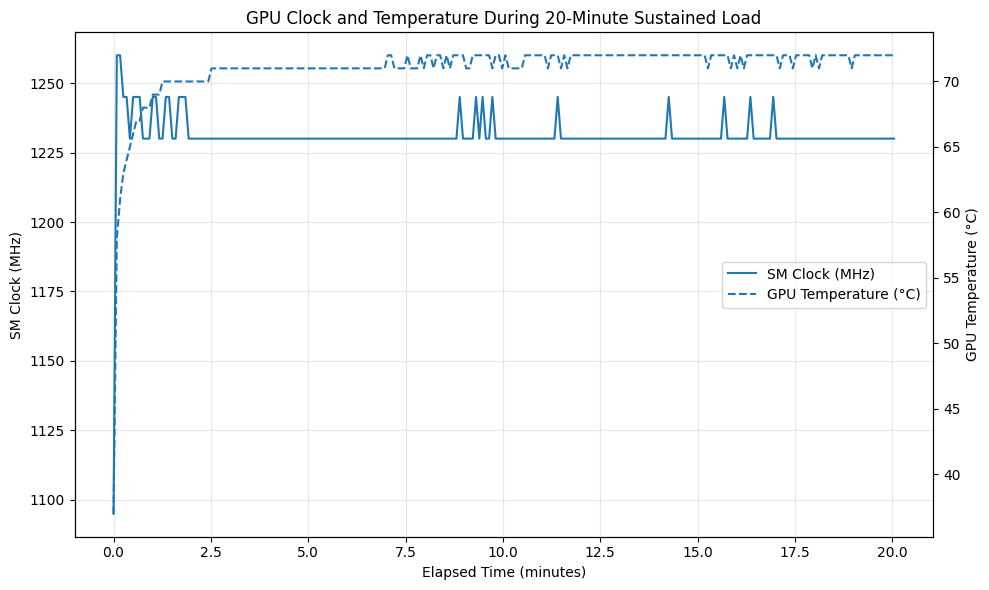

Saved: figures/part_e_clock_temperature.png


In [11]:
# ============================================================
# STEP 76 — CLOCK AND TEMPERATURE VS TIME
# ============================================================

import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

time_min = thermal_df["Elapsed_s"] / 60.0

fig, ax1 = plt.subplots(figsize=(10, 6))

# SM clock
line1 = ax1.plot(
    time_min,
    thermal_df["SM_Clock_MHz"],
    label="SM Clock (MHz)"
)

ax1.set_xlabel("Elapsed Time (minutes)")
ax1.set_ylabel("SM Clock (MHz)")
ax1.grid(True, alpha=0.3)

# Temperature on second y-axis
ax2 = ax1.twinx()

line2 = ax2.plot(
    time_min,
    thermal_df["Temperature_C"],
    linestyle="--",
    label="GPU Temperature (°C)"
)

ax2.set_ylabel("GPU Temperature (°C)")

# Combined legend
lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc="center right"
)

plt.title(
    "GPU Clock and Temperature During 20-Minute Sustained Load"
)

plt.tight_layout()

plt.savefig(
    "figures/part_e_clock_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: figures/part_e_clock_temperature.png"
)

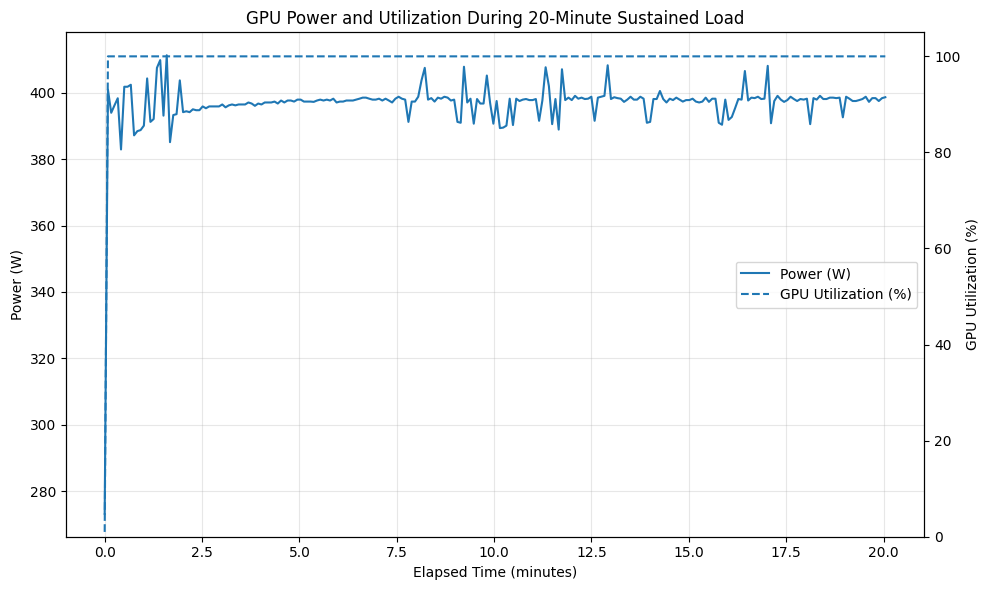

Saved: figures/part_e_power_utilization.png


In [12]:
# ============================================================
# STEP 77 — POWER AND GPU UTILIZATION VS TIME
# ============================================================

fig, ax1 = plt.subplots(figsize=(10, 6))

time_min = thermal_df["Elapsed_s"] / 60.0

line1 = ax1.plot(
    time_min,
    thermal_df["Power_W"],
    label="Power (W)"
)

ax1.set_xlabel("Elapsed Time (minutes)")
ax1.set_ylabel("Power (W)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

line2 = ax2.plot(
    time_min,
    thermal_df["GPU_Utilization_pct"],
    linestyle="--",
    label="GPU Utilization (%)"
)

ax2.set_ylabel("GPU Utilization (%)")
ax2.set_ylim(0, 105)

lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc="center right"
)

plt.title(
    "GPU Power and Utilization During 20-Minute Sustained Load"
)

plt.tight_layout()

plt.savefig(
    "figures/part_e_power_utilization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: figures/part_e_power_utilization.png"
)

In [13]:
# ============================================================
# STEP 78 — SAVE PART E SUMMARY
# ============================================================

part_e_summary = pd.DataFrame([{
    "GPU_UUID": thermal_df["GPU_UUID"].iloc[0],

    "Peak_Throughput_First_30s_TFLOPS":
        peak_first_30,

    "Steady_State_Final_5min_TFLOPS":
        steady_tflops,

    "Steady_State_vs_Peak_pct":
        steady_vs_peak_pct,

    "Maximum_Temperature_C":
        max_temp,

    "Loaded_Average_Temperature_C":
        loaded_avg_temp,

    "Maximum_Power_W":
        max_power,

    "Loaded_Average_Power_W":
        loaded_avg_power,

    "Loaded_Min_SM_Clock_MHz":
        loaded_min_clock,

    "Loaded_Max_SM_Clock_MHz":
        loaded_max_clock,

    "Thermal_Throttle_Observed":
        "No evidence observed",

    "Throttle_Onset_s":
        "None observed"
}])

part_e_summary.to_csv(
    "part_e_thermal_summary.csv",
    index=False
)

print("=== PART E FINAL SUMMARY ===")

print(
    f"Peak throughput (first 30 s) : "
    f"{peak_first_30:.2f} TFLOPS"
)

print(
    f"Steady throughput (final 5m) : "
    f"{steady_tflops:.2f} TFLOPS"
)

print(
    f"Steady / Peak                : "
    f"{steady_vs_peak_pct:.2f}%"
)

print(
    f"Maximum temperature          : "
    f"{max_temp:.1f} C"
)

print(
    f"Loaded temperature           : "
    f"{loaded_avg_temp:.1f} C average"
)

print(
    f"Maximum power                : "
    f"{max_power:.2f} W"
)

print(
    f"Loaded power                 : "
    f"{loaded_avg_power:.2f} W average"
)

print(
    f"Loaded SM clock range        : "
    f"{loaded_min_clock:.0f}-{loaded_max_clock:.0f} MHz"
)

print("Thermal throttling           : No evidence observed")
print("Throttle onset               : None observed")

print()
print("Saved: part_e_thermal_summary.csv")

=== PART E FINAL SUMMARY ===
Peak throughput (first 30 s) : 261.61 TFLOPS
Steady throughput (final 5m) : 257.66 TFLOPS
Steady / Peak                : 98.49%
Maximum temperature          : 72.0 C
Loaded temperature           : 71.2 C average
Maximum power                : 411.34 W
Loaded power                 : 397.33 W average
Loaded SM clock range        : 1230-1260 MHz
Thermal throttling           : No evidence observed
Throttle onset               : None observed

Saved: part_e_thermal_summary.csv


## Part E — Sustained Load and Thermal Analysis

The GPU was subjected to a sustained matrix-multiplication workload for
approximately 20 minutes, while GPU clock frequency, memory clock,
temperature, power draw, and utilization were sampled every five seconds.

The peak throughput measured during the first 30 seconds was approximately
261.61 TFLOPS. The average steady-state throughput during the final five
minutes was approximately 257.66 TFLOPS, corresponding to 98.49% of the
initial peak throughput.

During sustained high utilization, the SM clock remained in the range of
approximately 1230–1260 MHz. GPU temperature increased during the initial
warm-up period and then stabilized near 71–72 °C. The maximum observed
temperature was 72 °C.

Average power under high utilization was approximately 397.33 W, with a
maximum observed value of 411.34 W. The GPU therefore operated near a
roughly 400 W sustained power level during the workload.

No clear evidence of thermal throttling was observed in the collected
telemetry. After reaching thermal steady state, the clock frequency and
throughput remained stable, and the final-five-minute throughput retained
98.49% of the peak measured during the first 30 seconds. Therefore, no
thermal-throttle onset time is reported for this run.

In [83]:
# ============================================================
# STEP 80 — COLLECT VALUES FOR TABLE HW2.5.1
# ============================================================

import pandas as pd
import os

print("=== PART F — AVAILABLE RESULT FILES ===")

files_to_check = [
    "part_b_matmul_results.csv",
    "part_c_bandwidth_results.csv",
    "part_c_results.csv",
    "part_d_attention_boundary_summary.csv",
    "part_e_thermal_summary.csv"
]

for f in files_to_check:
    print(f"{f:42s} :", "FOUND" if os.path.exists(f) else "not found")

print("\n=== PART B RESULTS ===")

part_b = pd.read_csv("part_b_matmul_results.csv")

# Show BF16 measurements
bf16_rows = part_b[
    part_b["Precision"].astype(str).str.upper() == "BF16"
]

display(bf16_rows)

print("\n=== PART D BOUNDARY RESULTS ===")

part_d = pd.read_csv(
    "part_d_attention_boundary_summary.csv"
)

display(part_d)

print("\n=== PART E RESULTS ===")

part_e = pd.read_csv(
    "part_e_thermal_summary.csv"
)

display(part_e)

=== PART F — AVAILABLE RESULT FILES ===
part_b_matmul_results.csv                  : FOUND
part_c_bandwidth_results.csv               : not found
part_c_results.csv                         : not found
part_d_attention_boundary_summary.csv      : FOUND
part_e_thermal_summary.csv                 : FOUND

=== PART B RESULTS ===


,N,Precision,Mean_ms,Std_ms,TFLOPS,Repetitions,GPU_UUID,Theoretical_TFLOPS,Percent_of_Peak
12,1024,BF16,0.040038,0.007475,53.635600,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,312.0,17.190897
13,4096,BF16,0.532070,0.004764,258.309716,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,312.0,82.791576
14,8192,BF16,4.018739,0.126802,273.596161,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,312.0,87.691077
15,16384,BF16,32.379289,0.230223,271.658000,20,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,312.0,87.069872



=== PART D BOUNDARY RESULTS ===


,Method,Largest_Tested_Success,Smallest_Tested_Failure,OOM_Result,GPU_UUID
0,Naive Attention,25344,25600,Bracketed between 25344 and 25600,GPU-4a3d609e-89cf-640b-8162-5adf66e41fde
1,Fused Attention,4194304,Not observed,No OOM observed through 4194304 tokens,GPU-4a3d609e-89cf-640b-8162-5adf66e41fde



=== PART E RESULTS ===


,GPU_UUID,Peak_Throughput_First_30s_TFLOPS,Steady_State_Final_5min_TFLOPS,Steady_State_vs_Peak_pct,Maximum_Temperature_C,Loaded_Average_Temperature_C,Maximum_Power_W,Loaded_Average_Power_W,Loaded_Min_SM_Clock_MHz,Loaded_Max_SM_Clock_MHz,Thermal_Throttle_Observed,Throttle_Onset_s
0,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2,261.605088,257.660584,98.492191,72.0,71.154812,411.34,397.325314,1230.0,1260.0,No evidence observed,None observed


In [84]:
# ============================================================
# STEP 81 — LOCATE EXISTING PART C RESULTS
# ============================================================

import os
import pandas as pd

print("=== CSV FILES CURRENTLY AVAILABLE ===")
for f in sorted(os.listdir(".")):
    if f.endswith(".csv"):
        print(f)

print("\n=== POSSIBLE PART C DATAFRAMES IN MEMORY ===")

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        cols = [str(c) for c in obj.columns]

        keywords = [
            "bandwidth",
            "arithmetic",
            "intensity",
            "gb/s",
            "gbs",
            "roofline"
        ]

        if (
            "part_c" in name.lower()
            or any(
                keyword in " ".join(cols).lower()
                for keyword in keywords
            )
        ):
            print("\nDataFrame:", name)
            print("Shape:", obj.shape)
            print("Columns:", cols)
            display(obj)

print("\n=== POSSIBLE PART C VARIABLES ===")

for name, value in list(globals().items()):
    lname = name.lower()

    if any(x in lname for x in [
        "bandwidth",
        "arithmetic_intensity",
        "roofline"
    ]):
        if not isinstance(value, pd.DataFrame):
            try:
                print(name, "=", value)
            except:
                pass

=== CSV FILES CURRENTLY AVAILABLE ===
part_b_matmul_results.csv
part_d_attention_boundary_summary.csv
part_d_attention_comparison.csv
part_d_fused_attention.csv
part_d_fused_attention_extended.csv
part_d_naive_attention.csv
part_d_naive_attention_all.csv
part_d_naive_attention_final.csv
part_e_thermal_summary.csv
thermal_log.csv
thermal_test_30s.csv
thermal_throughput.csv

=== POSSIBLE PART C DATAFRAMES IN MEMORY ===

=== POSSIBLE PART C VARIABLES ===
memory_bandwidth_gbs = 1381.2493937106929
SPECIFIED_BANDWIDTH_GBS = 1555.0
bandwidth_percent = 88.82632756981947
PEAK_BANDWIDTH_GBS = 1555.0


In [85]:
# ============================================================
# STEP 82 — RECOVER AND SAVE PART C BANDWIDTH RESULT
# ============================================================

import pandas as pd

part_c_recovered = pd.DataFrame([{
    "Operation": "Memory-bound benchmark",
    "Effective_Bandwidth_GBs": memory_bandwidth_gbs,
    "Specified_Bandwidth_GBs": SPECIFIED_BANDWIDTH_GBS,
    "Percent_of_Specified_Bandwidth": bandwidth_percent,
    "GPU_UUID": gpu_uuid
}])

part_c_recovered.to_csv(
    "part_c_bandwidth_results.csv",
    index=False
)

print("=== PART C BANDWIDTH RESULT RECOVERED ===")
display(part_c_recovered.round(3))

print("\nSaved: part_c_bandwidth_results.csv")

=== PART C BANDWIDTH RESULT RECOVERED ===


,Operation,Effective_Bandwidth_GBs,Specified_Bandwidth_GBs,Percent_of_Specified_Bandwidth,GPU_UUID
0,Memory-bound benchmark,1381.249,1555.0,88.826,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2



Saved: part_c_bandwidth_results.csv


In [86]:
# ============================================================
# STEP 83 — RECOVER ORIGINAL PART C UUID FROM RUN_LOG
# ============================================================

print("=== SEARCHING RUN_LOG.txt FOR PART C ===\n")

with open("RUN_LOG.txt", "r") as f:
    lines = f.readlines()

keywords = [
    "Part C",
    "PART C",
    "bandwidth",
    "Bandwidth",
    "1381",
    "1555",
    "88.826"
]

matches = []

for i, line in enumerate(lines):
    if any(k in line for k in keywords):
        start = max(0, i - 5)
        end = min(len(lines), i + 8)

        block = "".join(lines[start:end])

        if block not in matches:
            matches.append(block)

for j, block in enumerate(matches, 1):
    print(f"\n--- MATCH {j} ---")
    print(block)

if not matches:
    print("No Part C information found in RUN_LOG.txt.")

=== SEARCHING RUN_LOG.txt FOR PART C ===


--- MATCH 1 ---
GPU Assignment I: Precision, Bandwidth, and the Cost of Attention

STUDENT PARAMETERS
------------------------------------------------------------------------
SID4: 5996
SEED: 5996



--- MATCH 2 ---

LOWER PRECISION TEST
FP8 matmul attempt failed: NotImplementedError: "addmm_cuda" not implemented for 'Float8_e4m3fn'


PART C — BANDWIDTH VS COMPUTE
------------------------------------------------------------------------
GPU UUID: GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2

MEMORY-BOUND OPERATION
Operation: FP32 elementwise addition
Elements: 200000000
Warm-up runs: 10


--- MATCH 3 ---
Operation: FP32 elementwise addition
Elements: 200000000
Warm-up runs: 10
Timed runs: 30
Mean latency: 1.738 ms
Effective bandwidth: 1381.25 GB/s
Specified bandwidth: 1555.00 GB/s
Percent specified bandwidth: 88.83%
Arithmetic intensity: 0.0833 FLOPs/byte
Roofline classification: Memory-bound

COMPUTE-BOUND OPERATION
Operation: BF16 square matrix m

In [87]:
# ============================================================
# STEP 84 — TABLE HW2.5.1 FINAL SUMMARY
# ============================================================

import pandas as pd

# Peak BF16 result from Part B
part_b = pd.read_csv("part_b_matmul_results.csv")
bf16 = part_b[
    part_b["Precision"].astype(str).str.upper() == "BF16"
].copy()

peak_bf16 = bf16.loc[bf16["TFLOPS"].idxmax()]

# Part C
part_c = pd.read_csv("part_c_bandwidth_results.csv")

# Part D
part_d = pd.read_csv("part_d_attention_boundary_summary.csv")

naive = part_d[
    part_d["Method"].str.contains("Naive", case=False)
].iloc[0]

fused = part_d[
    part_d["Method"].str.contains("Fused", case=False)
].iloc[0]

# Part E
part_e = pd.read_csv("part_e_thermal_summary.csv").iloc[0]

summary = pd.DataFrame({
    "Metric": [
        "Peak achieved TFLOPS (BF16)",
        "% theoretical peak (BF16)",
        "Effective bandwidth (GB/s)",
        "Naive attention OOM length",
        "Fused attention OOM length",
        "Steady-state / peak throughput",
        "Throttle onset"
    ],

    "Result": [
        f"{peak_bf16['TFLOPS']:.2f} TFLOPS",
        f"{peak_bf16['Percent_of_Peak']:.2f}%",
        f"{part_c.iloc[0]['Effective_Bandwidth_GBs']:.2f} GB/s",
        "25,344 success; 25,600 failure",
        "No OOM observed through 4,194,304 tokens",
        f"{part_e['Steady_State_vs_Peak_pct']:.2f}%",
        "None observed"
    ],

    "Run / Provenance": [
        str(peak_bf16["GPU_UUID"]),
        str(peak_bf16["GPU_UUID"]),
        str(part_c.iloc[0]["GPU_UUID"]),
        str(naive["GPU_UUID"]),
        str(fused["GPU_UUID"]),
        str(part_e["GPU_UUID"]),
        str(part_e["GPU_UUID"])
    ]
})

print("=== TABLE HW2.5.1 — FINAL SUMMARY ===")
display(summary)

summary.to_csv(
    "table_hw2_5_1_summary.csv",
    index=False
)

print("\nSaved: table_hw2_5_1_summary.csv")

=== TABLE HW2.5.1 — FINAL SUMMARY ===


,Metric,Result,Run / Provenance
0,Peak achieved TFLOPS (BF16),273.60 TFLOPS,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
1,% theoretical peak (BF16),87.69%,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
2,Effective bandwidth (GB/s),1381.25 GB/s,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
3,Naive attention OOM length,"25,344 success; 25,600 failure",GPU-4a3d609e-89cf-640b-8162-5adf66e41fde
4,Fused attention OOM length,"No OOM observed through 4,194,304 tokens",GPU-4a3d609e-89cf-640b-8162-5adf66e41fde
5,Steady-state / peak throughput,98.49%,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2
6,Throttle onset,None observed,GPU-f5e42ed3-9b0a-7003-62dd-4fb887642ee2



Saved: table_hw2_5_1_summary.csv
